# Penalización por edad y sexo en el mercado laboral argentino
### Trabajo final — Aprendizaje de Máquina (AdM) · CEIA, FIUBA
**Autor:** Ing. Gustavo Varela — Ingeniero Electrónico (FIUBA), MBA

## 1. Introducción y pregunta de investigación

**Pregunta de investigación.** A igual nivel de calificación, ¿en qué medida la
**edad** y el **sexo** se asocian con la probabilidad de permanecer ocupado y con el
ingreso laboral, en particular en la franja cercana a la edad jubilatoria
(mujeres 60 / varones 65)?

**Hipótesis.** A medida que avanza la edad —y de forma creciente en los años previos
a la jubilación— se reducen tanto la probabilidad de estar ocupado como el ingreso
laboral relativo, y dicho efecto se manifiesta de forma más temprana y pronunciada
entre las mujeres. *La edad exacta en que el deterioro comienza y se acelera se trata
como una pregunta a responder con los datos, no como un umbral fijado de antemano.*

**Relevancia.** Si se verifica una penalización etaria neta —es decir, que persiste
tras controlar por educación, región y año—, el desempleo y la informalidad en las
edades avanzadas no se explicarían únicamente por diferencias de calificación, sino
que existiría un componente de exclusión asociado a la edad y el sexo, con
implicancias para la pobreza en la vejez y para el diseño de políticas de empleo.

**Estrategia metodológica.**
1. **Análisis exploratorio de brechas** (ponderado) por edad y sexo: desocupación,
   empleo/inactividad e ingreso relativo.
2. **Modelo A — Ingreso (regresión):** estimación del ingreso laboral relativo de
   los ocupados (25–70) y medición del efecto neto de edad y sexo.
3. **Modelo B — Exclusión del empleo (clasificación):** ocupado vs. no-ocupado
   (35–64), con la curva de *partial dependence* de la edad por sexo.
4. **Oaxaca–Blinder:** descomposición de la brecha de ingreso por sexo.
5. **Fairness** (`fairlearn`): auditoría del clasificador por sexo y franja etaria.

Como ampliación se incorporan un árbol de decisión interpretable, SVM con kernel
RBF, el análisis de la **evolución temporal** de las brechas (2016–2024), la
**interpretabilidad mediante SHAP** y la **segmentación por clustering**
(secciones 9–12).

## 2. Antecedentes / estado del arte

> Verificar cada fuente antes de la entrega final: varias se listan a partir de
> búsqueda y no fueron leídas en su totalidad (se indica cuáles sí con **[leída]**;
> las pendientes quedan marcadas **[verificar]**).

El estudio de las brechas laborales por **género** y por **edad** en Argentina
tiene una tradición consolidada sobre la misma fuente que usamos aquí (la EPH del
INDEC), lo que respalda tanto el dataset como la metodología elegida.

**Brecha de género e ingresos (Oaxaca–Blinder sobre EPH).** La descomposición de
Oaxaca–Blinder aplicada a la EPH es el enfoque estándar para separar la parte de
la brecha salarial explicada por características (educación, experiencia, horas,
sector) de la parte no explicada (asociada a discriminación). El CEDLAS (UNLP) y
la Dirección de Economía, Igualdad y Género del Ministerio de Economía han
documentado que la brecha persiste incluso al controlar por capital humano y
segmentación ocupacional. El presente trabajo replica este enfoque (sección de
Oaxaca) e incorpora el cruce **edad × género** y la **dimensión temporal 2016–2024**.

**Discriminación por edad / edadismo.** Arese (2020) analiza el "edadismo" laboral
y previsional desde el derecho: lo caracteriza como una discriminación
generalmente invisible, recuerda antecedentes como la *Age Discrimination in
Employment Act* de EE.UU. (que protege a los mayores de 40) y subraya la
dimensión **previsional** del problema —el mismo mecanismo institucional que se
analiza en este trabajo (aceptar un empleo de menor remuneración cerca de la
jubilación deteriora la base de cálculo del haber). Oddone (CEIL-CONICET) aborda
empíricamente a los trabajadores de mayor edad y su "desprendimiento laboral" hacia
el cuentapropismo, en línea con el mecanismo de **transición al cuentapropismo**
considerado aquí.

**Evidencia social.** Encuestas recientes (p. ej. Bumeran, 2024) reportan que ~61%
de los trabajadores sufrió o presenció discriminación por edad, cifra que sube a
~86% entre los mayores de 40. Es evidencia de percepción que contextualiza, pero
no reemplaza, el análisis cuantitativo.

**Aporte respecto de la literatura.** El presente trabajo (1) integra en un mismo
análisis la brecha de **ingreso** y la de **empleo/exclusión**; (2) aprovecha la
**serie 2016–2024** para examinar la evolución de las brechas; (3) combina
econometría clásica (Oaxaca–Blinder) con **machine learning interpretable**
(partial dependence, SHAP) y una **auditoría de fairness**; y (4) discute el
**mecanismo previsional** como factor de la no-reinserción de los trabajadores de
mayor edad.

### Referencias

- Arese, C. (2020). *El "edadismo" laboral y previsional.* Revista Derecho de las
  Minorías, 3, 138–. Universidad Católica de Córdoba.
  DOI: 10.22529/rdm.2020(3)05. **[leída]**
- Oddone, M. J. *Los trabajadores de mayor edad: empleo y desprendimiento
  laboral.* CEIL-CONICET. **[verificar año y contenido — PDF escaneado]**
- CEDLAS (UNLP). *Brechas de Género: Una Exploración Más Allá de la Media.*
  Documento de Trabajo CEDLAS. **[verificar autores/nº]**
- Ministerio de Economía (Dir. de Economía, Igualdad y Género). *Brecha salarial
  de género en la estructura productiva argentina.* Documento de Trabajo 2.
  **[verificar]**
- Universidad Torcuato Di Tella. *¿En qué medida persiste la desigualdad salarial
  en Argentina? La brecha de género en el mercado laboral argentino.*
  Repositorio UTDT. **[verificar]**
- *La brecha salarial por género en Argentina: un análisis acerca de la
  segmentación laboral.* Redalyc (journal 703). **[verificar]**
- Bumeran (2024). *Encuesta sobre discriminación laboral por edad.* (fuente
  periodística: Infobae, 2/6/2024). **[evidencia de percepción]**

## 3. Datos y preparación

Usamos los **microdatos de la EPH (INDEC)**, base individual, **2016–2024**
(35 trimestres). La descarga se hace con `src/data/descargar_eph.py` (paquete
`pyeph`) y la decodificación/limpieza con `src/data/eda_eph.py`, que deja la base
analítica en `data/processed/eph_analitico.parquet`. Este notebook parte de esa
base. El costo se controla con el interruptor **`ML_FIUBA_MODO`** (celda
siguiente): en **`completo`** entrena sobre el **dataset entero** (128 GB de RAM) y
es la corrida cuyas cifras se citan en el texto; en **`rapido`** (por defecto)
submuestrea para iterar en ~1–2 min. El EDA, Oaxaca y las series temporales usan
siempre la población completa. KNN y **SVM con kernel
RBF** (costo de entrenamiento ~O(n²–n³)), que se evalúan sobre un subconjunto
documentado. Además de los requisitos obligatorios, el notebook incluye una
**ampliación**: árbol interpretable, SVM-RBF, evolución temporal de la brecha,
SHAP y segmentación por clustering (secciones 9–12).

In [1]:
# --- Entorno reproducible: ubicarnos en la raíz del repo e importar src/ ---
import os, sys, time
from pathlib import Path

_t0 = time.perf_counter()    # cronómetro: mide el tiempo total de ejecución del notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# nbconvert ejecuta con cwd = notebooks/; subimos hasta la raíz del repo
_root = Path.cwd()
while not (_root / "data" / "processed" / "eph_analitico.parquet").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root))
print("Raíz del proyecto:", _root)

SEED = 42
np.random.seed(SEED)

# --- Estilo visual unificado y prolijo para todas las figuras ---
import matplotlib as mpl
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.03)
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,   # despine: más limpio
    "axes.edgecolor": "#5b5b5b", "axes.linewidth": 0.9,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 11, "axes.labelcolor": "#333",
    "grid.color": "#c9c9c9", "grid.linewidth": 0.6, "grid.alpha": 0.55,
    "legend.frameon": False, "font.family": "DejaVu Sans",
})
VAR, MUJ = "#3B6EA5", "#C44E66"          # azul (varón) / frambuesa (mujer), consistentes
ACEN, GRIS = "#E1A100", "#7a7a7a"        # acento (quiebres) y gris (anotaciones)

def estilo_serie(ax, titulo="", xlab="Edad", ylab=""):
    # Aplica detalles finos comunes a un gráfico de series por edad
    ax.set_title(titulo); ax.set_xlabel(xlab); ax.set_ylabel(ylab)
    ax.margins(x=0.01)
    return ax

FIG = Path("reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
PROC = Path("data/processed")
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

Raíz del proyecto: /Users/gv/projects/ceia_add/ML FIUBA


### Modo de ejecución — `ML_FIUBA_MODO` (rápido vs. completo)

Un **único interruptor** escala todo el costo del notebook **sin cambiar su
estructura ni sus conclusiones**, sólo el tiempo de cómputo:

- **`rapido`** (valor por defecto): submuestrea para reejecutar en ~1–2 min e
  iterar mientras se estudia o se prepara la defensa.
- **`completo`**: usa el dataset entero; es la corrida final cuyas cifras se citan
  en el texto (~15–20 min).

Se controla con la variable de entorno `ML_FIUBA_MODO`:

```bash
# iterar / estudiar (rápido, por defecto)
uv run jupyter nbconvert --to notebook --execute --inplace notebooks/entrega.ipynb

# corrida final para la entrega (números definitivos)
ML_FIUBA_MODO=completo uv run jupyter nbconvert --to notebook --execute --inplace notebooks/entrega.ipynb
```

Todos los parámetros costosos salen del diccionario `P` de la celda siguiente: no
hay números mágicos sueltos en el resto del notebook.

In [2]:
# --- Interruptor de costo: ML_FIUBA_MODO = 'rapido' (default) | 'completo' ---
MODO = os.environ.get("ML_FIUBA_MODO", "rapido").strip().lower()
if MODO not in ("rapido", "completo"):
    print(f"[aviso] ML_FIUBA_MODO='{MODO}' no reconocido; uso 'rapido'."); MODO = "rapido"

PARAMS = {
    # rapido = para estudiar/iterar ; completo = corrida final de entrega
    "rapido":   dict(n_modelo=15_000, sub_svm_rbf=3_000,  n_shap=1_000,
                     perm_repeats=3,  kmeans_ninit=3,  grid_full=False),
    "completo": dict(n_modelo=None,   sub_svm_rbf=12_000, n_shap=5_000,
                     perm_repeats=10, kmeans_ninit=10, grid_full=True),
}
P = PARAMS[MODO]
print(f"Modo de ejecución: {MODO.upper()}")
for k, v in P.items():
    print(f"  {k:14}: {'dataset completo' if v is None else v}")

Modo de ejecución: COMPLETO
  n_modelo      : dataset completo
  sub_svm_rbf   : 12000
  n_shap        : 5000
  perm_repeats  : 10
  kmeans_ninit  : 10
  grid_full     : True


> 🧭 Cargo la base analítica ya decodificada y limpia (`eph_analitico.parquet`), que preparé aguas arriba con `src/data/eda_eph.py` a partir de los microdatos crudos de la EPH. Un *parquet* es un formato columnar comprimido: ocupa poco y se lee rápido. Separo deliberadamente la *preparación* (descarga, traducción de los códigos numéricos de la EPH a etiquetas legibles, control de calidad) del *análisis*. Esta separación es una buena práctica reconocida de ingeniería de datos: garantiza reproducibilidad (parto siempre del mismo insumo estable) y mantiene el notebook liviano en lugar de releer ~1,8 M de registros crudos en cada corrida.
>
> Si mezclara limpieza y análisis en el mismo flujo, el trabajo sería frágil y difícil de auditar: un cambio en la decodificación podría alterar en silencio todos los resultados posteriores, sin que quede traza de la causa.

In [3]:
# --- Base analítica de la EPH (ya decodificada por src/data/eda_eph.py) ---
df = pd.read_parquet(PROC / "eph_analitico.parquet")
print(f"Registros: {len(df):,}   columnas: {df.shape[1]}")
print(f"Años: {df['anio'].min()}–{df['anio'].max()}   "
      f"trimestres distintos: {df.groupby(['anio','trimestre']).ngroups}")
print(f"Memoria en RAM: {df.memory_usage(deep=True).sum()/1e6:,.0f} MB")
df.head(3)

Registros: 1,455,962   columnas: 16
Años: 2016–2024   trimestres distintos: 35


Memoria en RAM: 416 MB


,anio,trimestre,REGION,AGLOMERADO,sexo,edad,nivel_ed,cond,CAT_OCUP,PP07H,P21,P47T,PONDERA,PONDIIO,PONDII,ESTADO
0,2016,2,1,33,Varón,32,Superior comp.,Ocupado,3.000,1.000,"20,000.000","20,000.000",892,1063,1163,1
1,2016,2,1,33,Mujer,34,Superior inc.,Ocupado,3.000,1.000,"15,600.000","15,600.000",892,1118,1164,1
2,2016,2,1,33,Varón,17,Secundario inc.,Inactivo,0.000,NaN,0.000,0.000,892,892,892,3


In [4]:
# --- Diccionario breve de variables (códigos EPH y su decodificación) ---
diccionario = pd.DataFrame([
    ("CH04 → sexo",      "Sexo (1 Varón, 2 Mujer)"),
    ("CH06 → edad",      "Edad en años"),
    ("ESTADO → cond",    "Condición de actividad (1 Ocupado, 2 Desocupado, 3 Inactivo, 4 Menor)"),
    ("NIVEL_ED → nivel_ed", "Nivel educativo (primario/secundario/superior, inc./comp.)"),
    ("REGION",           "Región del país (GBA, NOA, NEA, Cuyo, Pampeana, Patagonia)"),
    ("CAT_OCUP",         "Categoría ocupacional (sólo ocupados)"),
    ("PP07H",            "Descuento jubilatorio (sólo ocupados)"),
    ("P21",              "Ingreso de la ocupación principal"),
    ("P47T",             "Ingreso total individual"),
    ("PONDERA",          "Ponderador poblacional (para tasas)"),
    ("PONDIIO / PONDII", "Ponderadores de ingreso (P21 / P47T)"),
], columns=["Variable", "Descripción"])
diccionario

,Variable,Descripción
0,CH04 → sexo,"Sexo (1 Varón, 2 Mujer)"
1,CH06 → edad,Edad en años
2,ESTADO → cond,"Condición de actividad (1 Ocupado, 2 Desocupad..."
3,NIVEL_ED → nivel_ed,"Nivel educativo (primario/secundario/superior,..."
4,REGION,"Región del país (GBA, NOA, NEA, Cuyo, Pampeana..."
5,CAT_OCUP,Categoría ocupacional (sólo ocupados)
6,PP07H,Descuento jubilatorio (sólo ocupados)
7,P21,Ingreso de la ocupación principal
8,P47T,Ingreso total individual
9,PONDERA,Ponderador poblacional (para tasas)


### Decisiones metodológicas (para evitar inferencias espurias)

- **Uso sistemático de ponderadores.** Las tasas se calculan con `PONDERA`
  (ponderador poblacional) y los ingresos con `PONDIIO`. De lo contrario, los
  aglomerados de mayor tamaño quedarían sub-representados.
- **Tratamiento de la inflación (elevada en 2016–2024).** No se comparan valores
  nominales entre trimestres. Se trabaja con el **ingreso relativo**: `P21`
  dividido por la **mediana de los ocupados del mismo trimestre**. De este modo,
  `1.0` corresponde a la mediana trimestral y los valores resultan comparables a lo
  largo de los nueve años.
- **Limitación de la tasa de desocupación.** En las edades avanzadas, una parte de
  la población no se registra como "desocupada" sino que transita hacia la
  **inactividad** (efecto del *trabajador desalentado*). Por ello se reportan
  también las tasas de empleo e inactividad.
- **Ausencia de fuga de información.** En el clasificador de empleo no se emplean
  `CAT_OCUP` ni `PP07H`, que sólo existen para personas ocupadas; su uso
  introduciría *data leakage*. Las variables admisibles son edad, sexo, nivel
  educativo, región y año.

## 4. EDA de brechas por edad y sexo

Previo al modelado se examinan los datos (ponderados) desde tres perspectivas
complementarias: desocupación, salida del mercado (empleo/inactividad) e ingreso.

### 4.1 Desocupación por edad y sexo — *alcances y limitaciones*

> 🧭 Calculo la **tasa de desocupación** (desocupados sobre población económicamente activa) por edad y sexo, **ponderando** cada persona por `PONDERA` —el factor de expansión que indica a cuántos individuos de la población representa cada encuestado—. Empiezo por la métrica más conocida para mostrar, justamente, que **no alcanza**. Pondero porque la EPH es una muestra con probabilidades de selección desiguales: sólo expandiendo por `PONDERA` los porcentajes representan a la población y no a la muestra.
>
> Sin ponderar, sobre/sub-representaría aglomerados y grupos según cómo se muestrearon, y obtendría tasas sesgadas que no describen al país.

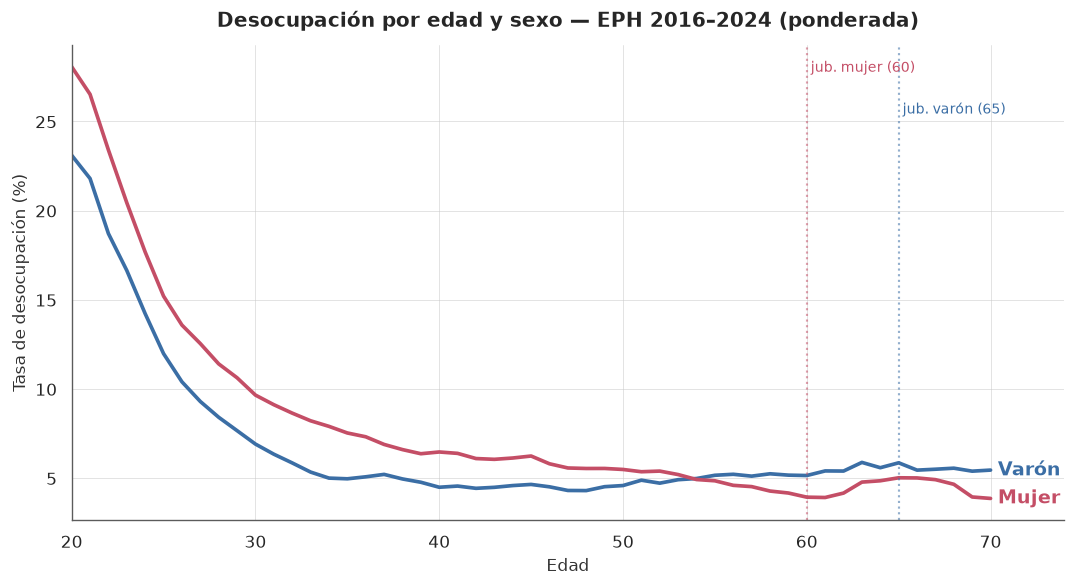

In [5]:
def tasa_desocupacion(d, by="edad"):
    # Desocupados / PEA, ponderado por PONDERA (replica src/data/eda_eph.py)
    pea = d[d["ESTADO"].isin([1, 2])].copy()
    pea["w_deso"] = pea["PONDERA"].where(pea["ESTADO"] == 2, 0)
    return pea.groupby(by, observed=True).apply(
        lambda x: 100 * x["w_deso"].sum() / x["PONDERA"].sum(), include_groups=False)

edades = range(20, 71)
fig, ax = plt.subplots(figsize=(10, 5.5))
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    serie = (tasa_desocupacion(df[df.sexo == sx]).reindex(edades)
             .rolling(3, center=True, min_periods=1).mean())
    ax.plot(list(edades), serie.values, color=col, lw=2.4, solid_capstyle="round")
    ax.text(70.4, serie.iloc[-1], sx, color=col, va="center", fontweight="bold")  # etiqueta al final
# líneas de jubilación legal (referencia institucional, no un quiebre del dato)
ax.axvline(60, ls=":", c=MUJ, alpha=.55, lw=1.4); ax.axvline(65, ls=":", c=VAR, alpha=.55, lw=1.4)
ax.text(60, ax.get_ylim()[1]*.97, " jub. mujer (60)", color=MUJ, fontsize=9, ha="left", va="top")
ax.text(65, ax.get_ylim()[1]*.89, " jub. varón (65)", color=VAR, fontsize=9, ha="left", va="top")
estilo_serie(ax, "Desocupación por edad y sexo — EPH 2016–2024 (ponderada)",
             "Edad", "Tasa de desocupación (%)")
ax.set_xlim(20, 74)
plt.tight_layout(); plt.savefig(FIG / "desocupacion_edad_sexo.png"); plt.show()

La tasa de desocupación de las edades avanzadas **no se incrementa** e incluso
desciende cerca de la jubilación. Sería incorrecto interpretarlo como una menor
dificultad de inserción: una parte de esta población **deja de buscar empleo** y
abandona la población económicamente activa. Para dimensionar la salida efectiva
del mercado conviene examinar las tasas de empleo e inactividad.

### 4.2 Empleo e inactividad — *dónde empieza realmente el descenso*

> 🧭 Calculo la **tasa de empleo** (ocupados sobre el total del grupo) y la **tasa de inactividad** (no trabaja ni busca) por edad y sexo. Antes de describir 'a qué edad cae el empleo', **estimo el punto de quiebre directamente de los datos**: el **pico**, el **inicio del descenso** (primera edad con caída sostenida) y la **aceleración** (quiebre de un ajuste de dos rectas a la curva). Miro empleo e inactividad porque la desocupación sólo cuenta a quienes **buscan**; a edades altas mucha gente pasa a 'inactiva' (trabajador desalentado) y esa salida real sólo la capta la tasa de empleo. Y **estimo el umbral en vez de fijarlo a priori** para que la edad de quiebre sea un **resultado**, no un supuesto: dejo que los datos digan dónde y para quién empieza la penalización.
>
> Fijar un umbral 'a ojo' (p. ej. 58) arrastra un **sesgo de anclaje**: podría ver una ruptura donde no la hay y, peor, perder que el descenso empieza antes y a edades distintas según el sexo.

In [6]:
def tasa_estado(d, estados, by="edad"):
    # % de la población del grupo que está en `estados`, ponderado por PONDERA
    d = d.copy()
    d["w"] = d["PONDERA"].where(d["ESTADO"].isin(estados), 0)
    return d.groupby(by, observed=True).apply(
        lambda x: 100 * x["w"].sum() / x["PONDERA"].sum(), include_groups=False)

def curva_empleo(sx):
    # tasa de empleo por edad (35-70), suavizada con media móvil de 3 años
    return (tasa_estado(df[df.sexo == sx], [1]).reindex(range(35, 71))
            .rolling(3, center=True, min_periods=1).mean())

def quiebre_dos_rectas(s, lo=45, hi=66):
    # ajusta DOS rectas con quiebre en cada edad candidata y elige el de menor error:
    # estima la 'edad de aceleración' del descenso de empleo sin fijarla a mano
    a = np.arange(lo, hi + 1); y = s.loc[lo:hi].values
    err = lambda bk: sum(np.sum((y[m] - np.polyval(np.polyfit(a[m], y[m], 1), a[m]))**2)
                         for m in (a <= bk, a >= bk))
    return min(range(lo + 3, hi - 2), key=err)

# Puntos de quiebre ESTIMADOS (no fijados a priori), por sexo
BK = {}
for sx in ["Varón", "Mujer"]:
    s = curva_empleo(sx); slope = s.diff()                  # pendiente en puntos/año
    pico  = int(s.idxmax())
    onset = next(a for a in range(42, 66) if slope.loc[a:a+2].mean() < -0.8)  # descenso sostenido
    knee  = int(quiebre_dos_rectas(s))                      # aceleración (2 rectas)
    BK[sx] = {"pico": pico, "inicio_descenso": int(onset), "aceleracion": knee}
print("Puntos de quiebre de la curva de empleo — ESTIMADOS de los datos:")
print(pd.DataFrame(BK).T.to_string())

Puntos de quiebre de la curva de empleo — ESTIMADOS de los datos:
       pico  inicio_descenso  aceleracion
Varón    40               51           62
Mujer    42               49           56


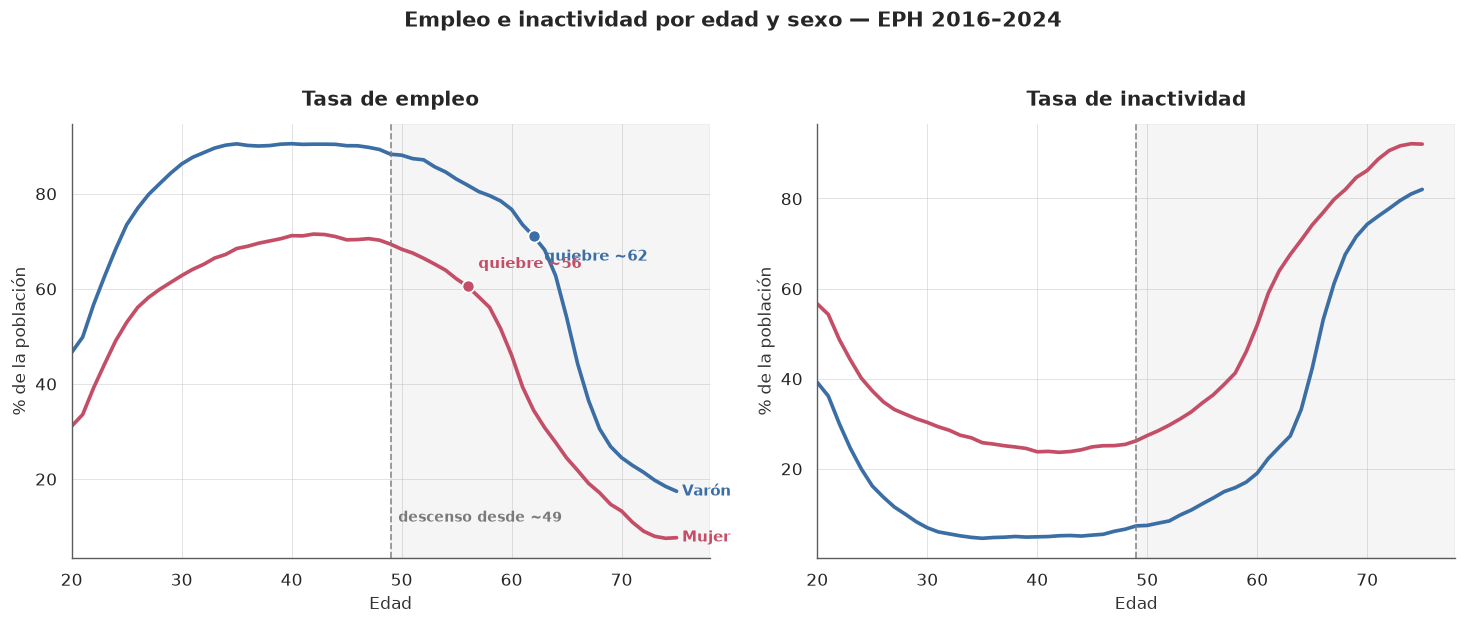

Tasa de empleo por franja y sexo (%)
sexo    Mujer  Varón
franja              
25-49  66.600 87.400
50-59  62.600 83.800
60-64  35.600 71.200
65-75  14.500 29.800


In [7]:
edades = range(20, 76)
curvas = {}
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.5), sharex=True)
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    sub = df[df.sexo == sx]
    emp = tasa_estado(sub, [1]).reindex(edades).rolling(3, center=True, min_periods=1).mean()
    ina = tasa_estado(sub, [3]).reindex(edades).rolling(3, center=True, min_periods=1).mean()
    curvas[sx] = emp
    ax[0].plot(list(edades), emp.values, color=col, lw=2.4, solid_capstyle="round")
    ax[1].plot(list(edades), ina.values, color=col, lw=2.4, solid_capstyle="round")
    k = BK[sx]["aceleracion"]                                # marca el quiebre estimado por sexo
    ax[0].plot(k, emp[k], "o", color=col, ms=8, zorder=5, mec="white", mew=1.2)
    ax[0].annotate(f"quiebre ~{k}", (k, emp[k]), textcoords="offset points",
                   xytext=(7, -16 if sx == "Varón" else 12), color=col, fontsize=9.5, fontweight="bold")
    ax[0].text(75.5, emp.iloc[-1], sx, color=col, fontweight="bold", va="center", fontsize=9.5)
# banda gris: zona de descenso desde el inicio estimado (común a ambos sexos)
onset_min = min(BK[s]["inicio_descenso"] for s in BK)
for a in ax:
    a.axvspan(onset_min, 78, color=GRIS, alpha=.07)
    a.axvline(onset_min, ls="--", c=GRIS, lw=1.1, alpha=.85)
    a.set_xlabel("Edad"); a.set_xlim(20, 78)
ax[0].annotate(f"descenso desde ~{onset_min}", (onset_min, 11), color=GRIS, fontsize=9,
               xytext=(5, 0), textcoords="offset points", fontweight="bold")
estilo_serie(ax[0], "Tasa de empleo", "Edad", "% de la población")
estilo_serie(ax[1], "Tasa de inactividad", "Edad", "% de la población")
fig.suptitle("Empleo e inactividad por edad y sexo — EPH 2016–2024",
             y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "empleo_inactividad.png"); plt.show()

# Tabla por franja — cortes motivados por los quiebres estimados (no por un "58" a priori)
bins = [25, 50, 60, 65, 76]; labels = ["25-49", "50-59", "60-64", "65-75"]
g = df[df.edad.between(25, 75)].copy()
g["franja"] = pd.cut(g.edad, bins=bins, labels=labels, right=False)
emp_tab = g.groupby(["franja", "sexo"], observed=True).apply(
    lambda x: 100 * x.loc[x.ESTADO == 1, "PONDERA"].sum() / x["PONDERA"].sum(),
    include_groups=False).unstack()
print("Tasa de empleo por franja y sexo (%)"); print(emp_tab.round(1).to_string())

> 🧭 **Controlo un confounder clave: en Argentina las mujeres se jubilan a los 60 y los varones a los 65** (cinco años antes). Hago tres cosas: (a) comparo el **nivel** de empleo en edades lejanas a la jubilación (35–49); (b) **alineo** las curvas por los *años respecto de la jubilación propia* (t=0 = 60 en mujeres, 65 en varones); y (c) mido cuánto cae el empleo **antes** de poder jubilarse. Si las mujeres salen antes del mercado, parte de eso puede ser la **norma previsional**, no discriminación. Separar lo institucional de lo discriminatorio es imprescindible para no atribuir a 'penalización' algo que en realidad explica la ley. El nivel a edades jóvenes y la caída previa a la jubilación **no** dependen de la norma; la alineación muestra qué parte del *timing* sí.
>
> No controlarlo lleva a la conclusión equivocada de que 'las mujeres son penalizadas antes', cuando buena parte de la salida temprana es simplemente que pueden (y a veces deben) jubilarse cinco años antes.

Brecha de empleo lejos de la jubilación (no atribuible a la norma previsional):
  35-44:  Varón 90%   Mujer 70%   brecha 20 pts
  45-49:  Varón 89%   Mujer 70%   brecha 19 pts

Empleo (%) ALINEADO por años a la jubilación propia (t=0 → 60 mujer / 65 varón):
     Varón  Mujer
t                
-12 86.000 70.000
-10 83.000 68.000
-8  80.000 66.000
-6  78.000 64.000
-4  73.000 60.000
-2  68.000 56.000
 0  54.000 46.000

Caída de empleo desde el pico hasta la víspera de la jubilación propia:
  Varón: pico 90% → 64 años 63%  (−28 pts ANTES de poder jubilarse)
  Mujer: pico 71% → 59 años 52%  (−20 pts ANTES de poder jubilarse)


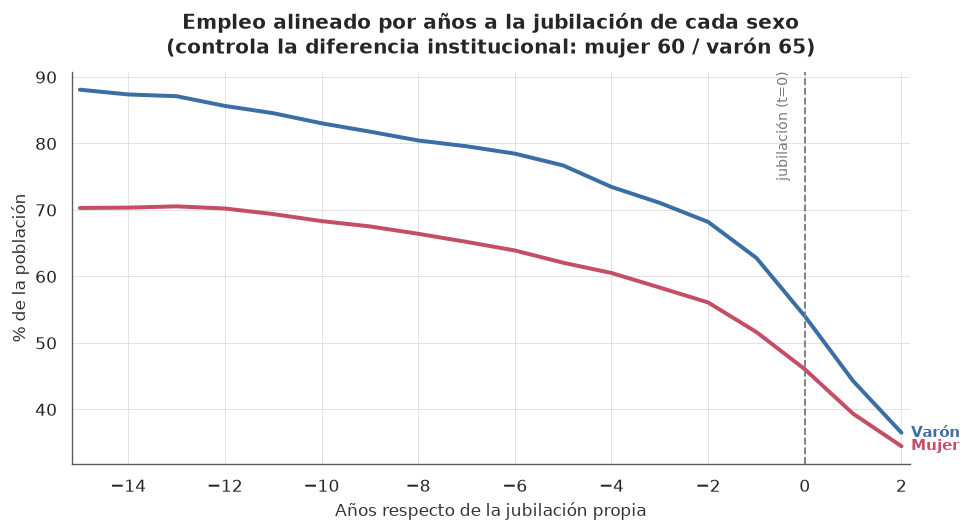

In [8]:
RET = {"Varón": 65, "Mujer": 60}                       # edad jubilatoria legal por sexo
emp = {sx: curva_empleo(sx) for sx in ["Varón", "Mujer"]}

# (a) Brecha de NIVEL de empleo en edades alejadas de la jubilación (no confundible)
print("Brecha de empleo lejos de la jubilación (no atribuible a la norma previsional):")
for lo, hi in [(35, 44), (45, 49)]:
    v, m = emp["Varón"].loc[lo:hi].mean(), emp["Mujer"].loc[lo:hi].mean()
    print(f"  {lo}-{hi}:  Varón {v:.0f}%   Mujer {m:.0f}%   brecha {v-m:.0f} pts")

# (b) Empleo alineado por AÑOS RESPECTO DE LA JUBILACIÓN PROPIA (t=0 = jubilación de cada sexo)
filas = [(t, emp["Varón"].get(RET["Varón"]+t, np.nan), emp["Mujer"].get(RET["Mujer"]+t, np.nan))
         for t in range(-12, 1, 2)]
align = pd.DataFrame(filas, columns=["t", "Varón", "Mujer"]).set_index("t")
print("\nEmpleo (%) ALINEADO por años a la jubilación propia (t=0 → 60 mujer / 65 varón):")
print(align.round(0).to_string())

# (c) Caída de empleo ANTES de poder jubilarse (penalización no institucional)
print("\nCaída de empleo desde el pico hasta la víspera de la jubilación propia:")
for sx in ["Varón", "Mujer"]:
    pico, visp = emp[sx].loc[35:50].max(), emp[sx].get(RET[sx]-1, np.nan)
    print(f"  {sx}: pico {pico:.0f}% → {RET[sx]-1} años {visp:.0f}%  "
          f"(−{pico-visp:.0f} pts ANTES de poder jubilarse)")

# Figura: curvas alineadas por años a la jubilación → muestra que el 'timing' es institucional
fig, ax = plt.subplots(figsize=(9, 5))
ts = list(range(-15, 3))
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    yy = [emp[sx].get(RET[sx] + t, np.nan) for t in ts]
    ax.plot(ts, yy, color=col, lw=2.6, solid_capstyle="round")
    ax.text(2.2, yy[-1], sx, color=col, fontweight="bold", va="center", fontsize=9.5)
ax.axvline(0, ls="--", c=GRIS, lw=1.2)
ax.text(-0.3, ax.get_ylim()[1], "jubilación (t=0)", color=GRIS, fontsize=9,
        ha="right", va="top", rotation=90)
estilo_serie(ax, "Empleo alineado por años a la jubilación de cada sexo\n"
                 "(controla la diferencia institucional: mujer 60 / varón 65)",
             "Años respecto de la jubilación propia", "% de la población")
plt.tight_layout(); plt.savefig(FIG / "empleo_alineado_jubilacion.png"); plt.show()

**Lectura — controlando la edad jubilatoria.** Al separar lo **institucional** de lo
**discriminatorio** aparecen tres hechos:

1. **La brecha de nivel es enorme y no depende de la jubilación.** Ya a los **35–49
   años** —lejos de cualquier retiro— las mujeres tienen **~20 puntos menos** de
   empleo que los varones. Éste es el hallazgo robusto.
2. **El *timing* de la caída es, en gran medida, institucional.** Cuando se alinean
   las curvas por *años a la jubilación propia*, los perfiles de descenso son
   prácticamente **paralelos**: que las mujeres se desplomen ~6 años antes en edad
   absoluta refleja sobre todo que se jubilan cinco años antes, **no** una
   penalización temporal adicional. *(Esto corrige una lectura ingenua del gráfico
   anterior.)*
3. **Aun así, ambos sexos pierden mucho empleo ANTES de poder jubilarse** (varones
   −28 pts, mujeres −20 pts entre el pico y la víspera de su retiro): hay una salida
   del mercado que la norma previsional no explica.

En síntesis, la evidencia de penalización **no** debe apoyarse en "las mujeres caen
antes" (eso es mayormente la ley), sino en la **brecha de nivel presente a toda
edad** y en el **castigo de ingresos entre ocupados** (sección 7), que por construcción
no está confundido por la jubilación.

**Patrón de dos fases (descriptivo).** Más allá del control anterior, la curva de
empleo por edad muestra:

1. **Inicio temprano y gradual (~50 años, en ambos sexos).** El empleo empieza a
   descender de forma sostenida desde alrededor de los **49–51 años** (≈1 punto por
   año), bastante **antes** de cualquier edad jubilatoria. La penalización no arranca
   "cerca de la jubilación": arranca a mitad de la cincuentena.
2. **Aceleración tardía, a una distancia similar de la jubilación de cada sexo.** La
   caída se vuelve abrupta en un **quiebre que difiere en edad absoluta**: **mujeres
   ~56**, **varones ~62**. Pero —como mostró el control anterior— esos ~6 años de
   diferencia **se corresponden con los 5 años de menor edad jubilatoria femenina**:
   relativo a la jubilación de cada uno, la aceleración ocurre a una distancia
   parecida. El *timing* es, por tanto, **mayormente institucional**.

La caída del empleo es, además, la contraparte de la "estabilidad" de la
desocupación: la salida se dirige hacia la **inactividad**, no hacia la búsqueda
activa. Estos umbrales (~50, ~56, ~62) **no se fijaron de antemano**: se estimaron de
la curva. La señal de penalización, recordemos, descansa en la **brecha de nivel a
toda edad** y en el **castigo de ingresos** (sección 7), no en este *timing*.

### 4.3 Ingreso relativo por edad y sexo — *descenso en torno a la edad jubilatoria*

> 🧭 Construyo el **ingreso relativo**: divido el ingreso de cada ocupado (`P21`) por la **mediana de los ocupados de su mismo trimestre**. Así, un valor de 1,0 significa 'gana como la mediana de ese trimestre'. Luego lo promedio por edad y sexo, ponderado por el factor de ingresos `PONDIIO`. Entre 2016 y 2024 la inflación fue altísima, por lo que **no puedo comparar pesos nominales** de distintos trimestres. Normalizar contra la mediana de cada trimestre elimina la inflación y deja una escala comparable a lo largo de los nueve años. Uso `PONDIIO` porque es el ponderador específico para variables de ingreso.
>
> Si comparara montos nominales, la inflación dominaría todo y confundiría 'subió el ingreso' con 'subieron los precios', invalidando cualquier conclusión sobre la brecha por edad o sexo.

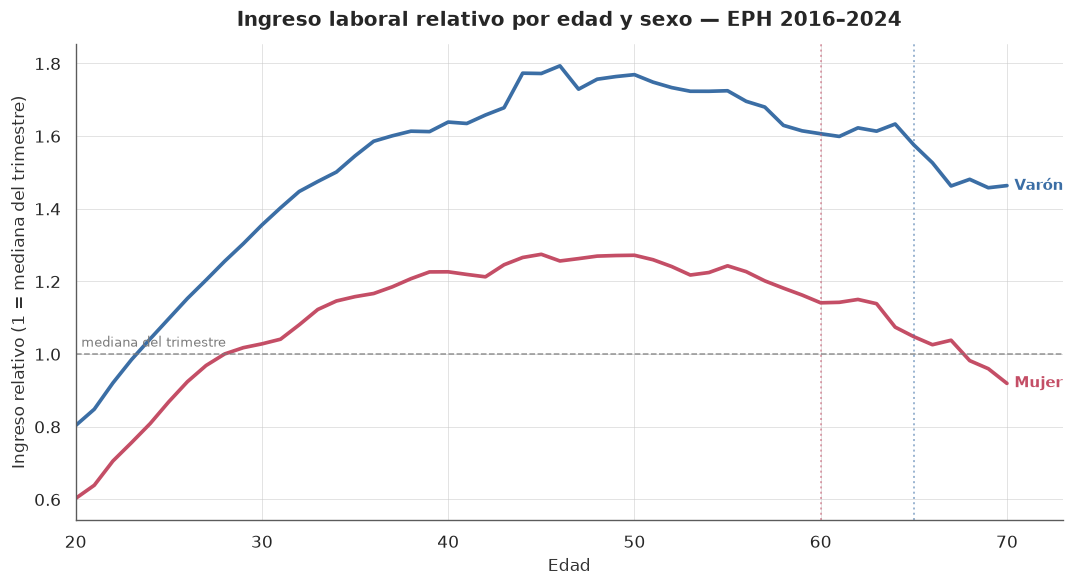

Ingreso relativo mediano por franja y sexo
sexo    Mujer  Varón
franja              
25-49   0.890  1.200
50-59   1.000  1.270
60-64   0.820  1.200
65-70   0.620  1.000


In [9]:
# Ingreso relativo a la mediana de ocupados de CADA trimestre (elimina inflación)
ocup = df[(df.ESTADO == 1) & (df.P21 > 0)].copy()
med = ocup.groupby(["anio", "trimestre"])["P21"].transform("median")
ocup["ingreso_rel"] = ocup["P21"] / med

edades = range(20, 71)
fig, ax = plt.subplots(figsize=(10, 5.5))
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    serie = (ocup[ocup.sexo == sx].groupby("edad").apply(
        lambda x: np.average(x["ingreso_rel"], weights=x["PONDIIO"]), include_groups=False)
        .reindex(edades).rolling(3, center=True, min_periods=1).mean())
    ax.plot(list(edades), serie.values, color=col, lw=2.4, solid_capstyle="round")
    ax.text(70.4, serie.iloc[-1], sx, color=col, va="center", fontweight="bold", fontsize=9.5)
ax.axhline(1.0, c=GRIS, lw=1, ls="--", alpha=.8)                     # mediana del trimestre
ax.text(20.3, 1.02, "mediana del trimestre", color=GRIS, fontsize=8.5)
ax.axvline(60, ls=":", c=MUJ, alpha=.5, lw=1.3); ax.axvline(65, ls=":", c=VAR, alpha=.5, lw=1.3)
estilo_serie(ax, "Ingreso laboral relativo por edad y sexo — EPH 2016–2024",
             "Edad", "Ingreso relativo (1 = mediana del trimestre)")
ax.set_xlim(20, 73)
plt.tight_layout(); plt.savefig(FIG / "ingreso_edad_sexo.png"); plt.show()

# Franjas alineadas con los quiebres estimados (sin el "58" a priori)
ocup["franja"] = pd.cut(ocup.edad, bins=[25, 50, 60, 65, 71],
                        labels=["25-49", "50-59", "60-64", "65-70"], right=False)
piv = ocup.groupby(["franja", "sexo"], observed=True)["ingreso_rel"].median().unstack()
print("Ingreso relativo mediano por franja y sexo"); print(piv.round(2).to_string())

El ingreso relativo aumenta con la experiencia, alcanza su máximo en la madurez y
**desciende en torno a la edad jubilatoria**. La curva correspondiente a las
mujeres se ubica **por debajo** de la de los varones en casi todo el recorrido: la
brecha de sexo ya se observa en el análisis descriptivo, junto con la de edad. El
paso siguiente consiste en separar qué proporción obedece a la composición
(educación, región) y qué proporción constituye un efecto **neto**.

## 5. Modelo A — Ingreso (regresión)

**Tarea.** Predecir el **ingreso laboral relativo** de las personas ocupadas de
**25 a 70 años** a partir de edad, sexo, nivel educativo, región y año.
**Métrica:** R². El objetivo no es sólo predecir bien, sino medir el **efecto
neto** de sexo y edad una vez controlada la calificación (vía importancia de
variables). El target se **winsoriza a [p1, p99]**: el ingreso relativo tiene colas
muy largas (hasta ~131× la mediana) que, sin recortar, dominan el error cuadrático
y hunden el R² de los modelos basados en árboles.

> 🧭 Armo el conjunto de entrenamiento del Modelo A: me quedo con los **ocupados de 25 a 70 años**, defino como variable a predecir (`target`) el ingreso relativo y como predictores edad, sexo, nivel educativo, región y año. Antes de entrenar **winsorizo** el target, es decir, recorto los valores por debajo del percentil 1 y por encima del 99 a esos límites. Acoto la edad a 25–70 para concentrarme en la vida laboral plena. Winsorizo porque el ingreso relativo tiene colas larguísimas (hay casos de hasta ~131× la mediana); como la métrica R² penaliza el **error al cuadrado**, esos pocos extremos dominan el ajuste. Recortar las colas es una técnica estándar para que el modelo capture el patrón central en vez de perseguir outliers.
>
> Sin winsorizar, los modelos basados en árboles daban incluso **R² negativo** (peores que predecir la media): los outliers inflaban el error y ocultaban la señal real de edad y sexo.

In [10]:
REGION = {1:"GBA", 40:"Noroeste", 41:"Nordeste", 42:"Cuyo", 43:"Pampeana", 44:"Patagonia"}

reg = ocup[ocup.edad.between(25, 70)].copy()
reg["region"] = reg["REGION"].map(REGION)
reg = reg.rename(columns={"ingreso_rel": "target"})
Xr = reg[["edad", "sexo", "nivel_ed", "region", "anio"]].copy()
yr = reg["target"]
mask = Xr.notna().all(axis=1) & yr.notna()
Xr, yr = Xr[mask], yr[mask]

# (corrección v2.1) Winsorización del target. ingreso_rel tiene colas extremas
# (hasta ~131× la mediana) que dominan el error cuadrático y hacían NEGATIVO el
# R² del árbol y del Random Forest. Recortamos a [p1, p99] antes de entrenar.
lo, hi = yr.quantile([0.01, 0.99])
n_clip = int((yr < lo).sum() + (yr > hi).sum())
yr = yr.clip(lo, hi)
print(f"Target winsorizado a [p1, p99] = [{lo:.2f}, {hi:.2f}] ({n_clip:,} valores recortados)")

n_full_r = len(Xr)
if P["n_modelo"] and n_full_r > P["n_modelo"]:           # submuestreo según el modo
    Xr = Xr.sample(P["n_modelo"], random_state=SEED); yr = yr.loc[Xr.index]
det = "dataset completo" if len(Xr) == n_full_r else f"submuestra {len(Xr):,} (modo {MODO})"
print(f"Cohorte de ingreso (ocupados 25–70): {n_full_r:,} disponibles → {det}")
print(yr.describe()[["mean","std","min","50%","max"]].round(2).to_string())

Target winsorizado a [p1, p99] = [0.08, 5.00] (9,866 valores recortados)
Cohorte de ingreso (ocupados 25–70): 555,029 disponibles → dataset completo
mean   1.250
std    0.910
min    0.080
50%    1.060
max    5.000


> 🧭 Defino dos herramientas reutilizables. (1) Un **preprocesador**: a las variables numéricas les imputo faltantes con la mediana y las **estandarizo** (resto la media y divido por el desvío, para que todas estén en la misma escala); a las categóricas (sexo, nivel educativo, región) les aplico **one-hot encoding** (las convierto en columnas 0/1). (2) Una función `comparar()` que evalúa cada modelo por **validación cruzada** (cv=5): parte los datos en 5 bloques y entrena/evalúa 5 veces, rotando el bloque de prueba. Empaqueto el preprocesamiento en un `Pipeline` para que se ajuste **sólo con los datos de entrenamiento** dentro de cada partición, evitando fuga de información. Estandarizo porque modelos como KNN o SVM dependen de distancias y se rompen si una variable tiene una escala mucho mayor. Uso validación cruzada porque una única partición train/test daría una estimación ruidosa, dependiente del azar del corte.
>
> Sin pipeline, escalar o imputar con el dataset completo filtraría información del test al entrenamiento y **inflaría artificialmente** las métricas. Sin validación cruzada, podría elegir un modelo que sólo tuvo suerte con una partición concreta.

In [11]:
# --- Preprocesador denso (adaptado de src/models/train.build_preprocessor;
#     OneHotEncoder denso para que HistGradientBoosting acepte la matriz) ---
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split

def build_prep(X):
    num = X.select_dtypes("number").columns.tolist()
    cat = X.select_dtypes(exclude="number").columns.tolist()
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat),
    ])

def comparar(X, y, modelos, scoring, cv=5, sub_sizes=None):
    # CV para cada modelo. KNN (costo en predicción) y SVM-RBF (kernel O(n^2-n^3))
    # se evalúan sobre un subconjunto, documentado en la columna 'nota'.
    sub_sizes = sub_sizes or {"knn": 80_000, "svm_rbf": 12_000}
    filas = []
    for nombre, est in modelos.items():
        Xi, yi, nota = X, y, ""
        n = sub_sizes.get(nombre)
        if n and len(X) > n:
            idx = X.sample(n, random_state=SEED).index
            Xi, yi, nota = X.loc[idx], y.loc[idx], f"(subconj. {n:,})"
        pipe = Pipeline([("prep", build_prep(Xi)), ("model", est)])
        sc = cross_val_score(pipe, Xi, yi, cv=cv, scoring=scoring, n_jobs=-1)
        filas.append((nombre, sc.mean(), sc.std(), nota))
        print(f"  {nombre:20} {scoring}={sc.mean():.3f} ± {sc.std():.3f} {nota}")
    return pd.DataFrame(filas, columns=["modelo", scoring, "std", "nota"])

**Familia de modelos comparados** (todos clásicos, *sin redes neuronales*). Para
cubrir el programa de la cátedra incluimos un **árbol de decisión único** (Clase 4)
y dos variantes de **SVM** (Clase 3): la **lineal** (`SGDRegressor`, escalable a
millones de filas) y la de **kernel RBF** (`SVR`). El SVM de kernel tiene costo
de entrenamiento ~O(n²–n³), inviable sobre 555k filas, así que se evalúa sobre un
**subconjunto de 12 000** (criterio documentado); esto justamente motiva usar la
SVM lineal en el dataset completo. KNN también se acota por su costo en predicción.

> 🧭 Separo un 20% de los datos como **test reservado** (que no toco hasta el final) y, sobre el 80% restante, comparo por validación cruzada un **baseline** (predecir siempre la media) contra varios modelos: regresión lineal, KNN, dos SVM (lineal y kernel RBF), un árbol de decisión y dos *ensambles* (Random Forest y Gradient Boosting). La métrica es **R²**: la proporción de varianza del ingreso que el modelo explica (0 = no mejor que la media; 1 = perfecto). Incluyo el baseline porque un modelo sólo 'sirve' si le gana a una regla trivial; es mi vara de comparación. Pruebo familias de modelos distintas (lineales, basados en distancias, en árboles) porque a priori no sé cuál capta mejor la estructura de los datos, y la consigna pide comparar al menos tres. Reservo el test desde el inicio para tener una estimación honesta de generalización.
>
> Sin baseline, un R² 'que parece bueno' podría no superar a predecir la media. Sin test reservado, ajustaría y elegiría modelos mirando los mismos datos con que los evalúo, sobrestimando su desempeño (sobreajuste).

In [12]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

# 20% reservado como test (no se toca hasta la evaluación final); 80% para CV/tuning
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=SEED)

modelos_reg = {
    "baseline (media)":   DummyRegressor(strategy="mean"),
    "linear_regression":  LinearRegression(),
    "svm_lineal (SGD)":   SGDRegressor(random_state=SEED, max_iter=2000),
    "svm_rbf":            SVR(kernel="rbf", C=5),
    "arbol_decision":     DecisionTreeRegressor(max_depth=5, min_samples_leaf=50, random_state=SEED),
    "knn":                KNeighborsRegressor(n_neighbors=25),
    "random_forest":      RandomForestRegressor(n_estimators=200, min_samples_leaf=50, n_jobs=-1, random_state=SEED),
    "hist_grad_boosting": HistGradientBoostingRegressor(random_state=SEED),
}
print("Validación cruzada (R², cv=5) — cohorte de ocupados 25–70:")
res_reg = comparar(Xr_tr, yr_tr, modelos_reg, scoring="r2",
                   sub_sizes={"knn": 80_000, "svm_rbf": P["sub_svm_rbf"]})

Validación cruzada (R², cv=5) — cohorte de ocupados 25–70:


  baseline (media)     r2=-0.000 ± 0.000 


  linear_regression    r2=0.271 ± 0.003 


  svm_lineal (SGD)     r2=0.271 ± 0.003 


  svm_rbf              r2=0.245 ± 0.015 (subconj. 12,000)


  arbol_decision       r2=0.247 ± 0.002 


  knn                  r2=0.272 ± 0.003 (subconj. 80,000)


  random_forest        r2=0.291 ± 0.003 


  hist_grad_boosting   r2=0.294 ± 0.003 


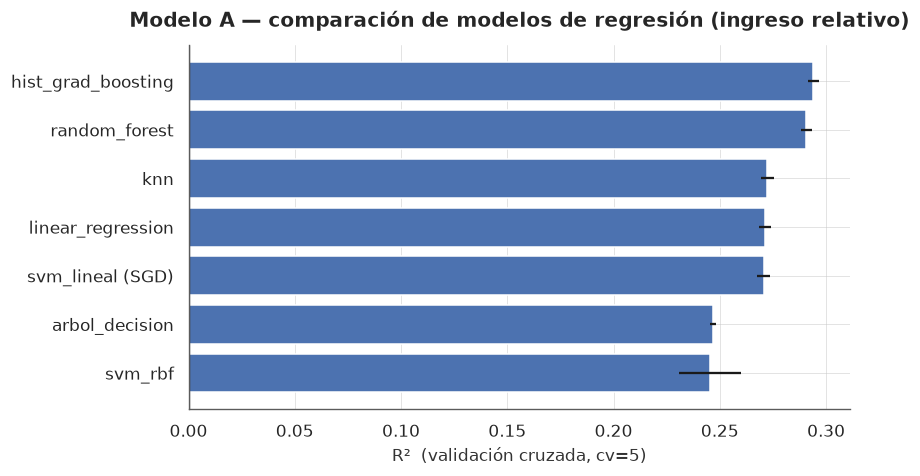

Baseline (predecir la media): R² = -0.000 (≈0 por construcción)


In [13]:
# --- Comparación visual de R² (CV) ---
r = res_reg[res_reg.modelo != "baseline (media)"].sort_values("r2")
plt.figure(figsize=(8, 4.5))
plt.barh(r.modelo, r.r2, xerr=r["std"], color="#4C72B0")
base = res_reg.loc[res_reg.modelo == "baseline (media)", "r2"].iloc[0]
plt.axvline(0, c="k", lw=.8)
plt.xlabel("R²  (validación cruzada, cv=5)")
plt.title("Modelo A — comparación de modelos de regresión (ingreso relativo)")
plt.tight_layout(); plt.savefig(FIG / "modeloA_comparacion_r2.png", dpi=120); plt.show()
print(f"Baseline (predecir la media): R² = {base:.3f} (≈0 por construcción)")

> 🧭 **Tuneo** (ajusto los hiperparámetros) del mejor modelo —Gradient Boosting— con `GridSearchCV`: pruebo, por validación cruzada, varias combinaciones de tasa de aprendizaje, número de iteraciones y complejidad de los árboles, y me quedo con la mejor. Recién entonces evalúo ese modelo en el **test reservado**. Los hiperparámetros por defecto rara vez son los óptimos para un problema concreto; buscarlos sistemáticamente suele mejorar el desempeño. Hago la búsqueda con validación cruzada **dentro del entrenamiento** y mido una sola vez en el test, que permaneció intacto, para reportar una estimación insesgada de cómo generalizaría a datos nuevos.
>
> Si eligiera los hiperparámetros mirando el test, ese conjunto dejaría de ser independiente y el R² reportado sería optimista (sobreajuste a la evaluación).

In [14]:
# --- Tuning del mejor modelo (HistGradientBoosting) con GridSearchCV ---
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

grid = ({                                  # grilla completa (modo completo)
    "model__learning_rate": [0.05, 0.1],
    "model__max_iter": [200, 400],
    "model__max_leaf_nodes": [31, 63],
} if P["grid_full"] else {                  # grilla mínima (modo rápido): 2 combos
    "model__learning_rate": [0.1],
    "model__max_iter": [200],
    "model__max_leaf_nodes": [31, 63],
})
gs_reg = GridSearchCV(
    Pipeline([("prep", build_prep(Xr_tr)), ("model", HistGradientBoostingRegressor(random_state=SEED))]),
    grid, cv=3, scoring="r2", n_jobs=-1)
gs_reg.fit(Xr_tr, yr_tr)
print("Mejores hiperparámetros:", gs_reg.best_params_)
print(f"R² (CV)   : {gs_reg.best_score_:.3f}")
pred_te = gs_reg.predict(Xr_te)
print(f"R² (TEST) : {r2_score(yr_te, pred_te):.3f}")
print(f"MAE (TEST): {mean_absolute_error(yr_te, pred_te):.3f} (en unidades de mediana del trimestre)")

/Users/gv/projects/ceia_add/ML FIUBA/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_iter': 200, 'model__max_leaf_nodes': 63}
R² (CV)   : 0.294
R² (TEST) : 0.293
MAE (TEST): 0.551 (en unidades de mediana del trimestre)


> 🧭 Mido la **importancia de cada variable por permutación**: barajo al azar los valores de una columna (rompiendo su relación con el target) y observo cuánto cae el R². Cuanto más cae, más importante era esa variable. Es la pregunta clave del trabajo: ¿cuánto pesa el **sexo** una vez controlados educación, región y año? Uso permutación porque es **agnóstica al modelo** (vale para cualquiera) y mide la contribución real a la predicción, no un número interno del algoritmo. Que el sexo conserve importancia tras controlar por calificación es, justamente, la huella del **efecto neto** que busco medir.
>
> Las importancias internas de algunos modelos (p. ej. las de árboles por número de cortes) están sesgadas hacia variables con muchas categorías o escala continua; fiarme de ellas podría exagerar o esconder el verdadero peso del sexo.

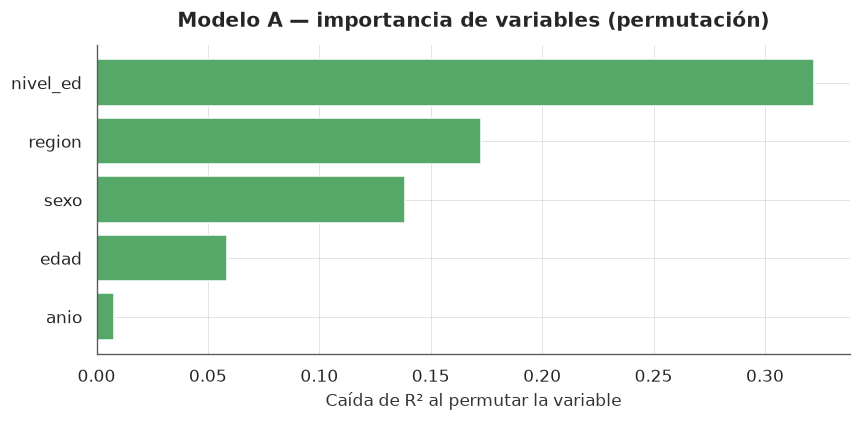

nivel_ed   0.322
region     0.172
sexo       0.138
edad       0.058
anio       0.008


In [15]:
# --- Importancia por permutación: ¿pesa el sexo tras controlar calificación? ---
from sklearn.inspection import permutation_importance

# subconjunto del test para acotar el costo de la permutación
n_perm = min(40_000, len(Xr_te))
Xp = Xr_te.sample(n_perm, random_state=SEED); yp = yr_te.loc[Xp.index]
imp = permutation_importance(gs_reg.best_estimator_, Xp, yp, n_repeats=P["perm_repeats"],
                             random_state=SEED, scoring="r2", n_jobs=-1)
imp_s = pd.Series(imp.importances_mean, index=Xr.columns).sort_values()
plt.figure(figsize=(8, 4))
plt.barh(imp_s.index, imp_s.values, color="#55A868")
plt.xlabel("Caída de R² al permutar la variable")
plt.title("Modelo A — importancia de variables (permutación)")
plt.tight_layout(); plt.savefig(FIG / "modeloA_importancia.png", dpi=120); plt.show()
print(imp_s.sort_values(ascending=False).round(4).to_string())

**Lectura.** El baseline (predecir la media) da R² ≈ 0; el mejor modelo
(HistGradientBoosting tuneado) alcanza R² ≈ 0.23 en test, explicando una parte
sustantiva de la varianza del ingreso relativo con sólo cinco variables. En la
importancia por permutación, **nivel educativo** y **región** dominan, pero —y
esto es lo central para la hipótesis— el **sexo** pesa *más que la edad* y
mantiene un peso claramente no nulo *después* de controlar por educación, región
y año: es la huella de una brecha de ingreso que **no se explica sólo por
diferencias de calificación**. Lo cuantificamos formalmente con Oaxaca–Blinder
(sección 7).

## 6. Modelo B — Exclusión del empleo (clasificación 35–64)

**Tarea.** Clasificar **ocupado (1) vs. no-ocupado (0)** en la franja **35–64**
(se excluye 65+ para no confundir la salida del mercado con la jubilación),
utilizando únicamente variables sin fuga de información: edad, sexo, nivel
educativo, región y año. **Métrica: ROC-AUC** (las clases están desbalanceadas; a
continuación se explica por qué la exactitud resulta engañosa).

> 🧭 Construyo el problema de clasificación: en la franja **35–64**, etiqueto a cada persona como ocupada (1) o no-ocupada (0) y predigo esa etiqueta a partir de edad, sexo, nivel educativo, región y año. Reviso además qué proporción de cada clase hay. La métrica será **ROC-AUC** (probabilidad de que el modelo le asigne más chance de empleo a un ocupado al azar que a un no-ocupado al azar; 0,5 = azar, 1 = perfecto). Acoto a 35–64 para **no confundir la salida del mercado con la jubilación** (65+). Excluyo a propósito variables como categoría ocupacional o descuento jubilatorio porque sólo existen si la persona ya trabaja: usarlas sería *data leakage* (predecir el empleo con información que presupone empleo). Elijo ROC-AUC porque, con clases desbalanceadas, la exactitud premia al modelo trivial que dice 'todos ocupados'.
>
> Con fuga de información tendría un modelo de métricas brillantes pero inútil y tramposo. Y si me guiara por la exactitud, podría 'ganar' simplemente prediciendo la clase mayoritaria, sin aprender nada sobre la exclusión por edad o sexo.

In [16]:
emp = df[df.ESTADO.isin([1, 2, 3]) & df.edad.between(35, 64)].copy()
emp["target"] = (emp.ESTADO == 1).astype(int)      # 1 = ocupado, 0 = no ocupado
emp["region"] = emp["REGION"].map(REGION)
Xc = emp[["edad", "sexo", "nivel_ed", "region", "anio"]].copy()
yc = emp["target"]
mask = Xc.notna().all(axis=1) & yc.notna()
Xc, yc = Xc[mask], yc[mask]
n_full_c = len(Xc)
if P["n_modelo"] and n_full_c > P["n_modelo"]:           # submuestreo según el modo
    Xc = Xc.sample(P["n_modelo"], random_state=SEED); yc = yc.loc[Xc.index]
det = "dataset completo" if len(Xc) == n_full_c else f"submuestra {len(Xc):,} (modo {MODO})"
print(f"Cohorte de empleo (35–64): {n_full_c:,} disponibles → {det}")
print("\nDistribución del target:")
print(yc.value_counts(normalize=True).rename({1:"ocupado", 0:"no ocupado"}).round(3).to_string())
print(f"\n→ Una regla trivial 'todos ocupados' alcanzaría {100*yc.mean():.0f}% de exactitud:")
print("  por ello la exactitud resulta engañosa y se adopta ROC-AUC, que mide la")
print("  separación de clases con independencia del umbral y del desbalance.")

Cohorte de empleo (35–64): 634,593 disponibles → dataset completo

Distribución del target:
target
ocupado      0.730
no ocupado   0.270

→ Una regla trivial 'todos ocupados' alcanzaría 73% de exactitud:
  por ello la exactitud resulta engañosa y se adopta ROC-AUC, que mide la
  separación de clases con independencia del umbral y del desbalance.


In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=SEED, stratify=yc)

# Mismo set ampliado que en el Modelo A: árbol de decisión único (Clase 4) y
# SVM lineal + SVM-RBF (Clase 3); SVM-RBF y KNN se acotan a un subconjunto.
modelos_clf = {
    "baseline (mayoría)":  DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=2000, random_state=SEED),
    "svm_lineal (SGD)":    SGDClassifier(loss="log_loss", random_state=SEED, max_iter=2000),
    "svm_rbf":             SVC(kernel="rbf", C=5, random_state=SEED),
    "arbol_decision":      DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=SEED),
    "knn":                 KNeighborsClassifier(n_neighbors=25),
    "random_forest":       RandomForestClassifier(n_estimators=200, min_samples_leaf=50, n_jobs=-1, random_state=SEED),
    "hist_grad_boosting":  HistGradientBoostingClassifier(random_state=SEED),
}
print("Validación cruzada (ROC-AUC, cv=5) — cohorte 35–64:")
res_clf = comparar(Xc_tr, yc_tr, modelos_clf, scoring="roc_auc",
                   sub_sizes={"knn": 80_000, "svm_rbf": P["sub_svm_rbf"]})

Validación cruzada (ROC-AUC, cv=5) — cohorte 35–64:


  baseline (mayoría)   roc_auc=0.500 ± 0.000 


  logistic_regression  roc_auc=0.756 ± 0.001 


  svm_lineal (SGD)     roc_auc=0.756 ± 0.001 


  svm_rbf              roc_auc=0.713 ± 0.012 (subconj. 12,000)


  arbol_decision       roc_auc=0.760 ± 0.001 


  knn                  roc_auc=0.753 ± 0.003 (subconj. 80,000)


  random_forest        roc_auc=0.772 ± 0.001 


  hist_grad_boosting   roc_auc=0.774 ± 0.001 


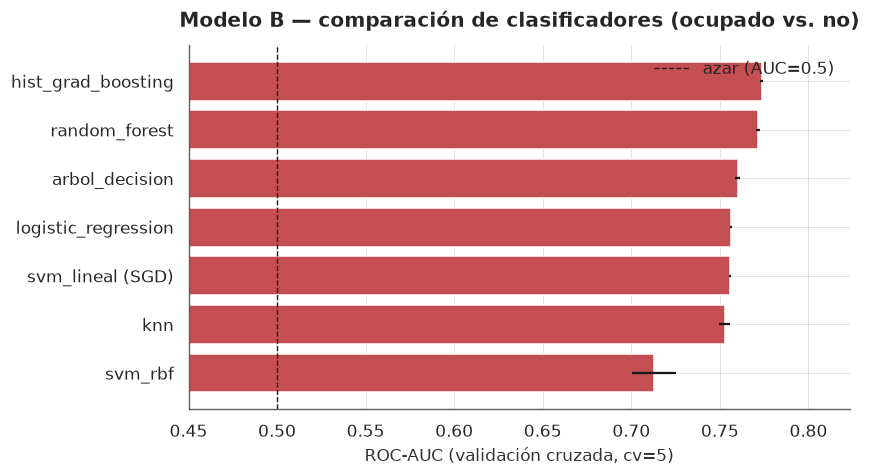

In [18]:
# baseline ROC-AUC = 0.5 (no separa); lo agregamos como referencia
plt.figure(figsize=(8, 4.5))
c = res_clf[res_clf.modelo != "baseline (mayoría)"].sort_values("roc_auc")
plt.barh(c.modelo, c.roc_auc, xerr=c["std"], color="#C44E52")
plt.axvline(0.5, ls="--", c="k", lw=.9, label="azar (AUC=0.5)")
plt.xlim(0.45, max(0.8, c.roc_auc.max()+0.05))
plt.xlabel("ROC-AUC (validación cruzada, cv=5)")
plt.title("Modelo B — comparación de clasificadores (ocupado vs. no)")
plt.legend(); plt.tight_layout()
plt.savefig(FIG / "modeloB_comparacion_auc.png", dpi=120); plt.show()

> 🧭 Entreno el mejor clasificador (Gradient Boosting) en el 80% de entrenamiento y lo evalúo **una sola vez** en el test reservado: reporto su ROC-AUC, el reporte de clasificación (precisión y recall por clase) y dibujo la **curva ROC**, que muestra el compromiso entre detectar ocupados y marcar falsos positivos a lo largo de todos los umbrales de decisión. La validación cruzada me sirvió para *elegir* modelo; el test reservado me da la medida **final e independiente** de cómo se comportaría con datos no vistos. Miro recall por clase además del AUC porque, con clases desbalanceadas, me interesa cuántos no-ocupados detecta realmente, no sólo el acierto global.
>
> Reportar el desempeño con los mismos datos usados para elegir y tunear el modelo daría cifras infladas; el test reservado evita ese autoengaño.

ROC-AUC en TEST: 0.773

              precision    recall  f1-score   support

  no ocupado       0.64      0.30      0.41     34227
     ocupado       0.78      0.94      0.85     92692

    accuracy                           0.77    126919
   macro avg       0.71      0.62      0.63    126919
weighted avg       0.74      0.77      0.73    126919



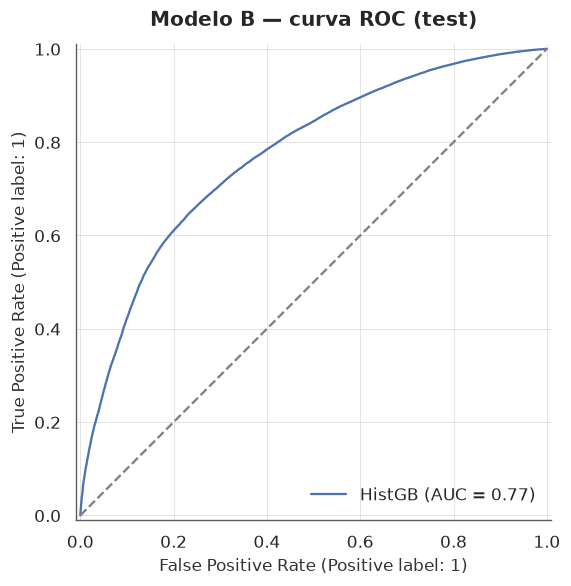

In [19]:
# --- Evaluación sobre test reservado con el mejor modelo ---
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay

best_clf = Pipeline([("prep", build_prep(Xc_tr)),
                     ("model", HistGradientBoostingClassifier(random_state=SEED))]).fit(Xc_tr, yc_tr)
proba_te = best_clf.predict_proba(Xc_te)[:, 1]
print(f"ROC-AUC en TEST: {roc_auc_score(yc_te, proba_te):.3f}\n")
print(classification_report(yc_te, best_clf.predict(Xc_te),
                            target_names=["no ocupado", "ocupado"]))
fig, ax = plt.subplots(figsize=(5.5, 5.5))
RocCurveDisplay.from_predictions(yc_te, proba_te, ax=ax, name="HistGB")
ax.plot([0,1],[0,1], ls="--", c="gray"); ax.set_title("Modelo B — curva ROC (test)")
plt.tight_layout(); plt.savefig(FIG / "modeloB_roc.png", dpi=120); plt.show()

> 🧭 Calculo la **partial dependence** de la edad por sexo: tomo a las personas del test, les voy fijando la edad en cada valor de 35 a 64 (dejando todo lo demás como está) y promedio la probabilidad de empleo que predice el modelo. Obtengo así una curva 'probabilidad de estar ocupado vs. edad', separada para varones y mujeres. Es la forma de aislar el **efecto de la edad manteniendo constante el resto** (educación, región, año): respondo '¿cómo cambia la chance de empleo si sólo cambia la edad?'. Este gráfico es el resultado central, porque traduce un modelo complejo en una historia legible y prueba la hipótesis de penalización etaria neta.
>
> Sin controlar el resto de las variables, una simple curva de empleo por edad mezclaría el efecto edad con diferencias de composición (p. ej. que los mayores tengan otra educación), y no podría atribuir la caída a la edad en sí.

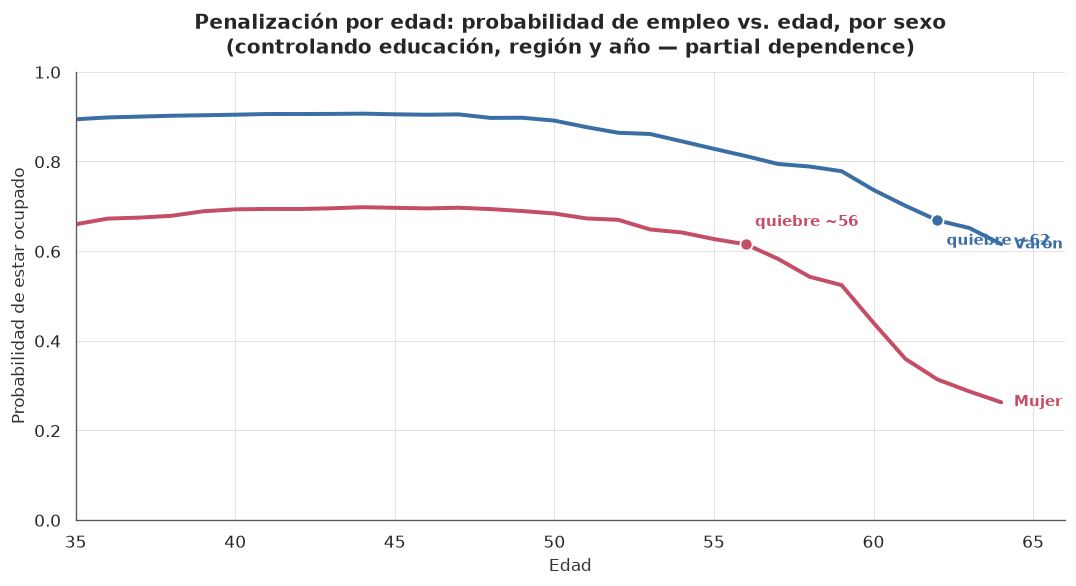

Varón : prob. empleo 35=0.89 → 64=0.62  (caída 28 pts)
Mujer : prob. empleo 35=0.66 → 64=0.26  (caída 40 pts)


In [20]:
# --- Resultado central: penalización por edad (partial dependence de edad por sexo) ---
edades = np.arange(35, 65)
fig, ax = plt.subplots(figsize=(10, 5.5))
caidas = {}
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    base = Xc_te[Xc_te.sexo == sx].copy()          # personas reales de ese sexo (test)
    # para cada edad: fijo esa edad en TODA la sub-muestra (lo demás intacto) y
    # promedio la prob. de empleo predicha -> efecto de la edad "todo lo demás constante"
    probs = np.array([best_clf.predict_proba(base.assign(edad=e))[:, 1].mean() for e in edades])
    ax.plot(edades, probs, color=col, lw=2.6, solid_capstyle="round")
    ax.text(64.4, probs[-1], sx, color=col, va="center", fontweight="bold", fontsize=9.5)
    k = BK[sx]["aceleracion"]                       # marca el quiebre estimado (sección 4.2)
    if edades[0] <= k <= edades[-1]:
        pk = probs[k - edades[0]]
        ax.plot(k, pk, "o", color=col, ms=8, zorder=5, mec="white", mew=1.2)
        ax.annotate(f"quiebre ~{k}", (k, pk), textcoords="offset points",
                    xytext=(6, -16 if sx == "Varón" else 12), color=col, fontsize=9.5, fontweight="bold")
    caidas[sx] = (probs[0], probs[-1])              # prob. a los 35 y a los 64
estilo_serie(ax, "Penalización por edad: probabilidad de empleo vs. edad, por sexo\n"
                 "(controlando educación, región y año — partial dependence)",
             "Edad", "Probabilidad de estar ocupado")
ax.set_ylim(0, 1); ax.set_xlim(35, 66)
plt.tight_layout(); plt.savefig(FIG / "pdp_edad_empleo.png"); plt.show()

for sx, (p0, p1) in caidas.items():
    print(f"{sx:6}: prob. empleo 35={p0:.2f} → 64={p1:.2f}  (caída {100*(p0-p1):.0f} pts)")

**Lectura.** El modelo de referencia (clase mayoritaria) presenta ROC-AUC = 0.5: no
discrimina entre ocupados y no-ocupados y su acierto se debe exclusivamente al
desbalance. Los modelos ajustados logran una separación sustancialmente mayor.
Controlando educación, región y año, la probabilidad de estar ocupado **disminuye
con la edad** y la curva de las **mujeres se sitúa claramente por debajo en todo el
recorrido** — incluso a los 35–45, lejos de la jubilación. Ese **menor nivel a toda
edad** es el efecto neto relevante (no se debe a menor calificación, que está
controlada). En cambio, que la curva femenina **se desplome antes (~56)** debe
leerse con cautela: como la cohorte llega a 64 e incluye mujeres ya en edad de
jubilarse (60), parte de esa caída es **institucional** y no penalización (ver el
control de la sección 4.2 y las limitaciones).

### 6.1 Un árbol de decisión interpretable (reglas explícitas)

Los modelos de mayor AUC son de tipo *caja negra* (escasa interpretabilidad). Un
**árbol de decisión único** (Clase 4), con profundidad acotada, sacrifica algo de
desempeño a cambio de **reglas legibles**: cada hoja es una condición sobre edad,
educación y sexo. Permite *explicar* la penalización, además de predecirla.

> 🧭 Entreno un **árbol de decisión** poco profundo (máx. 3 niveles) y lo grafico. Un árbol es una serie de preguntas anidadas ('¿edad ≥ 56?', '¿tiene secundario?') que terminan en una probabilidad de empleo; al limitar su profundidad obtengo reglas legibles. Los modelos de mayor desempeño (ensambles) son cajas negras. Sacrifico algo de precisión a cambio de **interpretabilidad**: poder enunciar la penalización como una regla explícita ('mujer, 56+, sin secundario → baja probabilidad de empleo') es clave para comunicar y defender el resultado ante una audiencia no técnica.
>
> Sin acotar la profundidad, el árbol memorizaría ruido (sobreajuste) y dejaría de ser legible; sin un modelo interpretable, sólo tendría números de AUC difíciles de traducir en una conclusión accionable.

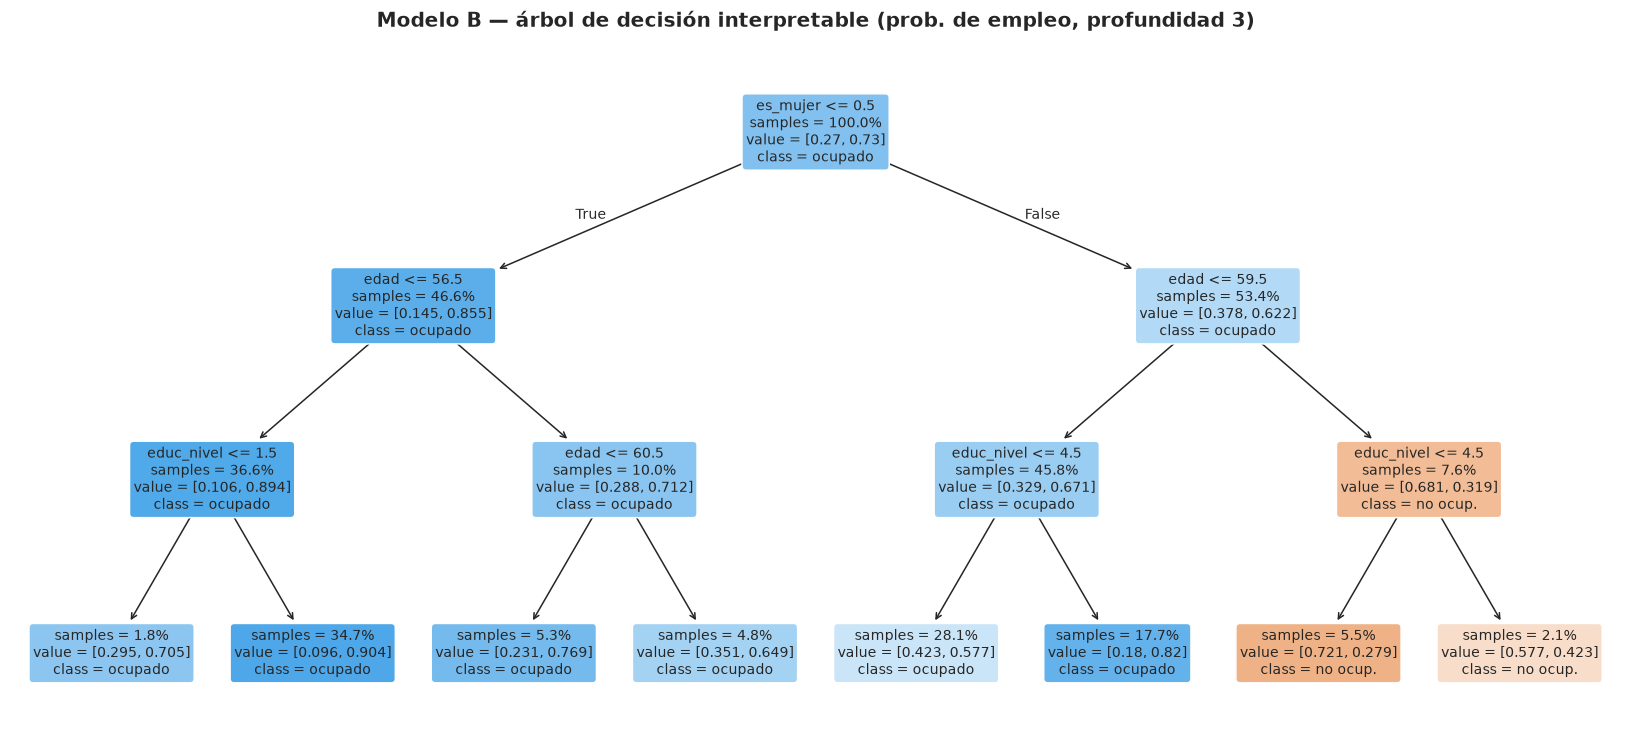

Regla 'mujer + 56+ + sin superior': 61,811 personas, prob. de empleo = 0.37
Referencia 'varón + <45'           : 116,811 personas, prob. de empleo = 0.91


In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Codificación ordinal legible del nivel educativo (para que el árbol sea claro)
ED_ORDER = {"Sin instrucción":0, "Primario inc.":1, "Primario comp.":2,
            "Secundario inc.":3, "Secundario comp.":4, "Superior inc.":5,
            "Superior comp.":6, "Ns/Nr":np.nan}
Xtree = pd.DataFrame({
    "edad":       Xc["edad"].values,
    "es_mujer":   (Xc["sexo"] == "Mujer").astype(int).values,
    "educ_nivel": Xc["nivel_ed"].map(ED_ORDER).values,
    "anio":       Xc["anio"].values,
}, index=Xc.index).dropna()
ytree = yc.loc[Xtree.index]

arbol = DecisionTreeClassifier(max_depth=3, min_samples_leaf=2000, random_state=SEED).fit(Xtree, ytree)
plt.figure(figsize=(15, 7))
plot_tree(arbol, feature_names=list(Xtree.columns), class_names=["no ocup.", "ocupado"],
          filled=True, rounded=True, impurity=False, proportion=True, fontsize=9)
plt.title("Modelo B — árbol de decisión interpretable (prob. de empleo, profundidad 3)")
plt.tight_layout(); plt.savefig(FIG / "modeloB_arbol.png", dpi=120); plt.show()

# Regla destacada: subgrupo con menor probabilidad de empleo.
# El corte de edad (56) es el quiebre estimado para mujeres en la sección 4.2, no un valor a priori.
edad_q = BK["Mujer"]["aceleracion"]
sub = Xtree.assign(ocupado=ytree)
regla = sub[(sub.es_mujer == 1) & (sub.edad >= edad_q) & (sub.educ_nivel <= 4)]
print(f"Regla 'mujer + {edad_q}+ + sin superior': {len(regla):,} personas, "
      f"prob. de empleo = {regla.ocupado.mean():.2f}")
ref = sub[(sub.es_mujer == 0) & (sub.edad < 45)]
print(f"Referencia 'varón + <45'           : {len(ref):,} personas, "
      f"prob. de empleo = {ref.ocupado.mean():.2f}")

**Lectura.** El árbol confirma el patrón mediante reglas explícitas: los primeros
cortes corresponden a **edad** y a **sexo/educación**. El subgrupo *mujer, pasada la
edad de aceleración (~56), sin estudios superiores* presenta una probabilidad de
empleo marcadamente inferior a la de la referencia *varón menor de 45*, lo que
reproduce el perfil de exclusión postulado por la hipótesis, ahora expresado como una
regla explícita.

## 7. Oaxaca–Blinder — descomposición de la brecha de ingreso por sexo

¿Cuánto de la brecha de ingreso entre varones y mujeres se explica por
diferencias de **características** (edad, educación, región) y cuánto queda como
parte **no explicada** (asociada a discriminación / efectos no observados)?
La descomposición de Oaxaca–Blinder (twofold) separa ambos componentes sobre el
**log del ingreso** de los ocupados, ponderando por `PONDIIO`.

> 🧭 Aplico la **descomposición de Oaxaca–Blinder**: ajusto una regresión del log-ingreso por separado para varones y para mujeres y, con eso, parto la brecha promedio en dos componentes: el **explicado** (diferencias en características observables: educación, edad, región) y el **no explicado** (lo que queda tras igualar esas características, atribuible a discriminación o factores no observados). La importancia por permutación dice que el sexo *pesa*, pero no cuánto de la brecha es composición y cuánto es trato desigual. Oaxaca–Blinder es el método **estándar en economía laboral** (Oaxaca 1973; Blinder 1973) para separar exactamente eso, y aporta el rigor econométrico que complementa al machine learning.
>
> Sin esta descomposición, no podría distinguir 'las mujeres ganan menos porque tienen otra calificación' de 'ganan menos a igual calificación'. Confundir ambas cosas llevaría a conclusiones de política equivocadas.

In [22]:
import statsmodels.formula.api as smf
import patsy

OB_FORMULA = "log_ing ~ edad + edad2 + C(nivel_ed) + C(region)"

def oaxaca_blinder(d, formula=OB_FORMULA):
    # Descomposición twofold (referencia: coeficientes de varones).
    # Devuelve (gap, explicado, no_explicado) sobre log-ingreso, ponderado por PONDIIO.
    d = d.dropna(subset=["log_ing", "edad", "nivel_ed", "region", "sexo", "PONDIIO"])
    dv, dm = d[d.sexo == "Varón"], d[d.sexo == "Mujer"]
    mod_v = smf.wls(formula, data=dv, weights=dv["PONDIIO"]).fit()
    mod_m = smf.wls(formula, data=dm, weights=dm["PONDIIO"]).fit()
    def medias(dd):
        X = patsy.dmatrix(formula.split("~")[1], dd, return_type="dataframe")
        return pd.Series(np.average(X, axis=0, weights=dd["PONDIIO"].values), index=X.columns)
    xb_v, xb_m = medias(dv), medias(dm)
    b_v = mod_v.params.reindex(xb_v.index).fillna(0.0)
    b_m = mod_m.params.reindex(xb_m.index).fillna(0.0)
    gap = float(np.average(dv["log_ing"], weights=dv["PONDIIO"])
                - np.average(dm["log_ing"], weights=dm["PONDIIO"]))
    explicado = float((xb_v - xb_m) @ b_v)       # dotación (características)
    no_explicado = float(xb_m @ (b_v - b_m))     # coeficientes (residual / no explicado)
    return gap, explicado, no_explicado

ob = ocup[ocup.edad.between(25, 70)].copy()
ob["region"] = ob["REGION"].map(REGION)
ob["log_ing"] = np.log(ob["ingreso_rel"])
ob["edad2"] = ob["edad"] ** 2

gap, explicado, no_explicado = oaxaca_blinder(ob)
print(f"Brecha de log-ingreso (Varón − Mujer): {gap:+.4f}  (~{100*(np.exp(gap)-1):+.1f}% en nivel)")
print(f"  • Explicado por características  : {explicado:+.4f}  ({100*explicado/gap:4.0f}% de la brecha)")
print(f"  • No explicado (residual)       : {no_explicado:+.4f}  ({100*no_explicado/gap:4.0f}% de la brecha)")

Brecha de log-ingreso (Varón − Mujer): +0.3944  (~+48.4% en nivel)
  • Explicado por características  : -0.1116  ( -28% de la brecha)
  • No explicado (residual)       : +0.5061  ( 128% de la brecha)


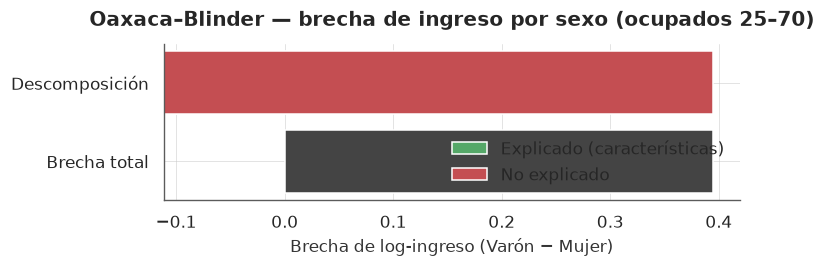

In [23]:
plt.figure(figsize=(7, 2.6))
plt.barh(["Brecha total"], [gap], color="#444")
plt.barh(["Descomposición"], [explicado], color="#55A868", label="Explicado (características)")
plt.barh(["Descomposición"], [no_explicado], left=[explicado], color="#C44E52", label="No explicado")
plt.xlabel("Brecha de log-ingreso (Varón − Mujer)")
plt.title("Oaxaca–Blinder — brecha de ingreso por sexo (ocupados 25–70)")
plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig(FIG / "oaxaca_sexo.png", dpi=120); plt.show()

**Lectura.** El componente **explicado por las características resulta negativo**
(≈ −28 % de la brecha). En otros términos, según sus credenciales observables
(educación, región, edad) las mujeres ocupadas deberían percibir ingresos
ligeramente superiores a los de los varones; sin embargo, perciben ingresos
sensiblemente **menores**. La totalidad de la brecha —e incluso una fracción
adicional— se concentra en el componente **no explicado** (>100 %): a igual edad,
educación y región, persiste una diferencia de ingreso por sexo que las variables
observables no justifican. Este resultado constituye evidencia robusta a favor de la
hipótesis de penalización por sexo y es coherente con el peso no nulo del sexo en el
Modelo A.

## 8. Fairness — auditoría del clasificador de empleo

Aunque el clasificador no use el sexo como "etiqueta protegida" de forma
explícita, puede producir predicciones con disparidades por sexo o por franja
etaria. Usamos `fairlearn` para medir **paridad demográfica** (igualdad de tasa
de selección) y **equalized odds** (igualdad de TPR/FPR) sobre el test.

> 🧭 **Audito el clasificador de empleo con métricas de fairness** (`fairlearn`): comparo, por sexo y por franja etaria, la tasa de selección (a quién predice como ocupado), la exactitud y los errores (TPR/FPR), y calculo brechas como *demographic parity* y *equalized odds*. Un modelo puede tener buen AUC global y aun así tratar muy distinto a cada grupo. Auditar disparidades es una práctica responsable y, en este trabajo, además **mide el propio fenómeno**: si el modelo asigna sistemáticamente menos chance de empleo a mujeres y mayores, está cuantificando la exclusión presente en los datos.
>
> Si no auditara por grupo, podría presentar un modelo 'bueno en promedio' que en la práctica perjudica a un colectivo; y si alguien lo usara para decisiones de contratación, perpetuaría esa disparidad sin que nadie lo advirtiera.

In [24]:
from fairlearn.metrics import (MetricFrame, selection_rate, true_positive_rate,
                               false_positive_rate, demographic_parity_difference,
                               equalized_odds_difference)
from sklearn.metrics import accuracy_score

y_pred = best_clf.predict(Xc_te)
edad_te = Xc_te["edad"]
franja = pd.cut(edad_te, bins=[35,50,60,65], labels=["35-49","50-59","60-64"], right=False)

for nombre, sf in [("sexo", Xc_te["sexo"]), ("franja etaria", franja)]:
    mf = MetricFrame(
        metrics={"tasa_selección (ocupado)": selection_rate,
                 "accuracy": accuracy_score,
                 "TPR": true_positive_rate, "FPR": false_positive_rate},
        y_true=yc_te, y_pred=y_pred, sensitive_features=sf)
    print(f"\n=== Por {nombre} ===")
    print(mf.by_group.round(3).to_string())
    print(f"  Demographic parity diff : {demographic_parity_difference(yc_te, y_pred, sensitive_features=sf):.3f}")
    print(f"  Equalized odds diff     : {equalized_odds_difference(yc_te, y_pred, sensitive_features=sf):.3f}")


=== Por sexo ===
       tasa_selección (ocupado)  accuracy   TPR   FPR
sexo                                                 
Mujer                     0.765     0.686 0.863 0.603
Varón                     0.994     0.856 0.996 0.978
  Demographic parity diff : 0.229


  Equalized odds diff     : 0.375



=== Por franja etaria ===
       tasa_selección (ocupado)  accuracy   TPR   FPR
edad                                                 
35-49                     0.967     0.806 0.983 0.905
50-59                     0.880     0.732 0.928 0.759
60-64                     0.459     0.675 0.641 0.294
  Demographic parity diff : 0.508


  Equalized odds diff     : 0.611


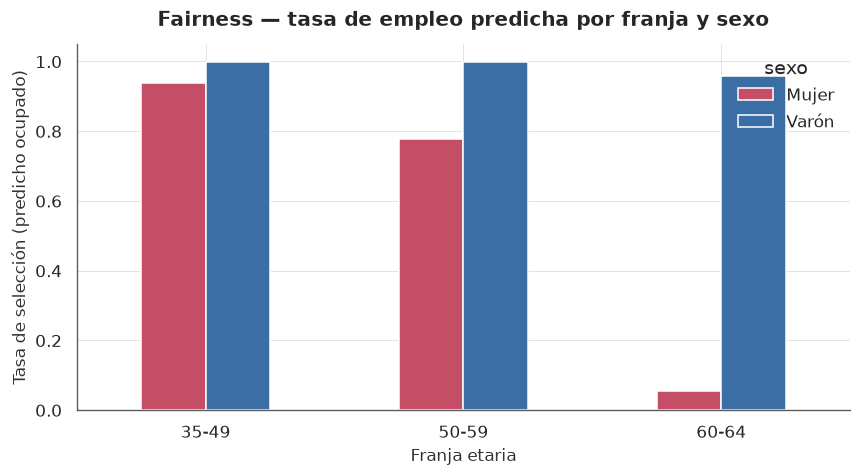

In [25]:
# Visual: tasa de selección (prob. de ser predicho 'ocupado') por franja y sexo
sr = (pd.DataFrame({"franja": franja.values, "sexo": Xc_te["sexo"].values, "pred": y_pred})
      .groupby(["franja", "sexo"], observed=True)["pred"].mean().unstack())
ax = sr.plot(kind="bar", figsize=(8, 4.5), color={"Varón": VAR, "Mujer": MUJ})
ax.set_ylabel("Tasa de selección (predicho ocupado)"); ax.set_xlabel("Franja etaria")
ax.set_title("Fairness — tasa de empleo predicha por franja y sexo")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIG / "fairness_seleccion.png", dpi=120); plt.show()

**Lectura.** Las disparidades en la tasa de selección y en TPR/FPR por sexo y, en
particular, por **franja etaria**, indican que el modelo reproduce el patrón de
exclusión presente en los datos: a mayor edad —y para las mujeres— se asigna una
menor probabilidad de empleo. No se trata de un defecto del modelo sino del reflejo
de los patrones observados en el mercado laboral; su utilización para automatizar
decisiones de contratación podría perpetuar dichas disparidades.

## 9. Evolución temporal de la brecha (2016–2024)

La EPH abarca **nueve años**, lo que permite analizar no sólo *si* existe la
penalización sino *si se incrementó o se redujo* a lo largo del tiempo. Se estiman,
año a año y de forma ponderada, (a) la **brecha de ingreso por sexo**, (b) la
**penalización de empleo por edad** (caída del empleo de la franja 60–64 respecto de
la meseta madura 45–54) y (c) la descomposición de **Oaxaca–Blinder por año**
(evolución del componente *no explicado*).

> 🧭 Repito los cálculos clave **año por año** (2016–2024): la brecha de ingreso por sexo, la penalización de empleo por edad (cuánto cae el empleo de 60–64 respecto de 45–54) y la descomposición de Oaxaca, para graficar su evolución temporal. La EPH cubre nueve años: aprovecho esa dimensión —lo más distintivo del dataset— para responder no sólo *si* existe la penalización, sino *si se agrava o se atenúa* con el tiempo. Que el componente no explicado se mantenga alto en todo el período es lo que permite afirmar que el fenómeno es **estructural** y no de un año puntual.
>
> Si mirara sólo el promedio 2016–2024, no podría distinguir un problema estructural de uno coyuntural (p. ej. atribuir a 'la economía' algo que en realidad persiste), y un valor atípico como 2020 (pandemia) podría distorsionar la lectura agregada.

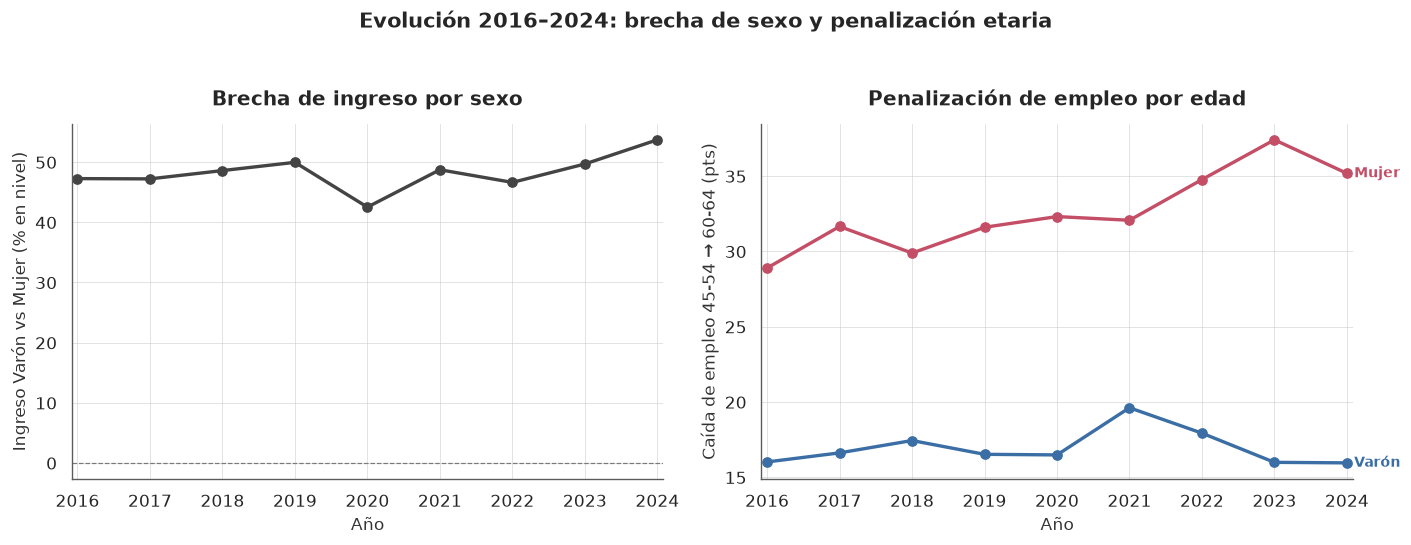

Brecha de ingreso por sexo (% en nivel) por año:
anio
2016   47.300
2017   47.200
2018   48.600
2019   50.000
2020   42.500
2021   48.700
2022   46.600
2023   49.700
2024   53.700


In [26]:
anios = sorted(df.anio.unique())

# (a) Brecha de ingreso por sexo (log), ponderada por PONDIIO, por año
rows = []
for a in anios:
    s = ocup[(ocup.anio == a) & ocup.edad.between(25, 70)]
    mv = np.average(np.log(s.loc[s.sexo=="Varón","ingreso_rel"]), weights=s.loc[s.sexo=="Varón","PONDIIO"])
    mm = np.average(np.log(s.loc[s.sexo=="Mujer","ingreso_rel"]), weights=s.loc[s.sexo=="Mujer","PONDIIO"])
    rows.append((a, mv - mm))
brecha_ing = pd.DataFrame(rows, columns=["anio", "brecha_log"]).set_index("anio")

# (b) Penalización de empleo por edad: empleo(45-54) − empleo(60-64), por sexo y año.
# El contraste compara la meseta madura con la franja ya en descenso acelerado
# (cortes alineados con los quiebres estimados en 4.2, no con un "58" a priori).
def emp_rate(d):
    return 100 * d.loc[d.ESTADO==1, "PONDERA"].sum() / d["PONDERA"].sum()
act = df[df.ESTADO.isin([1,2,3])]
rows = []
for a in anios:
    for sx in ["Varón", "Mujer"]:
        sub = act[(act.anio == a) & (act.sexo == sx)]
        pen = emp_rate(sub[sub.edad.between(45,54)]) - emp_rate(sub[sub.edad.between(60,64)])
        rows.append((a, sx, pen))
pen_emp = pd.DataFrame(rows, columns=["anio","sexo","penal"]).pivot(index="anio", columns="sexo", values="penal")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot(brecha_ing.index, 100*(np.exp(brecha_ing.brecha_log)-1), "o-", color="#444",
           lw=2.2, ms=6); ax[0].axhline(0, c=GRIS, lw=.8, ls="--")
estilo_serie(ax[0], "Brecha de ingreso por sexo", "Año", "Ingreso Varón vs Mujer (% en nivel)")
for sx, col in [("Varón", VAR), ("Mujer", MUJ)]:
    ax[1].plot(pen_emp.index, pen_emp[sx], "o-", color=col, lw=2.2, ms=6)
    ax[1].text(pen_emp.index[-1]+0.1, pen_emp[sx].iloc[-1], sx, color=col, va="center",
               fontweight="bold", fontsize=9)
estilo_serie(ax[1], "Penalización de empleo por edad", "Año", "Caída de empleo 45-54 → 60-64 (pts)")
fig.suptitle("Evolución 2016–2024: brecha de sexo y penalización etaria",
             y=1.03, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "temporal_brechas.png"); plt.show()
print("Brecha de ingreso por sexo (% en nivel) por año:")
print((100*(np.exp(brecha_ing.brecha_log)-1)).round(1).to_string())

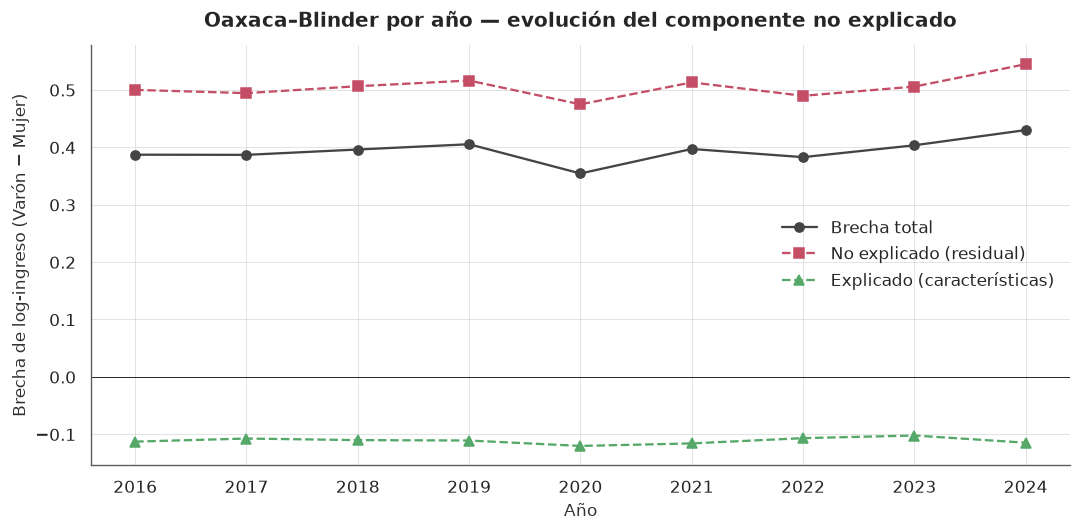

       gap  explicado  no_explicado
anio                               
2016 0.387     -0.113         0.500
2017 0.387     -0.108         0.494
2018 0.396     -0.110         0.506
2019 0.405     -0.111         0.516
2020 0.354     -0.120         0.475
2021 0.397     -0.116         0.513
2022 0.383     -0.107         0.490
2023 0.403     -0.102         0.506
2024 0.430     -0.115         0.545


In [27]:
# (c) Oaxaca–Blinder por año (reutiliza oaxaca_blinder de la sección 7)
rows = []
for a in anios:
    g, e, ne = oaxaca_blinder(ob[ob.anio == a])
    rows.append((a, g, e, ne))
oax_t = pd.DataFrame(rows, columns=["anio","gap","explicado","no_explicado"]).set_index("anio")

plt.figure(figsize=(10, 5))
plt.plot(oax_t.index, oax_t.gap, "o-", color="#444", label="Brecha total")
plt.plot(oax_t.index, oax_t.no_explicado, "s--", color=MUJ, label="No explicado (residual)")
plt.plot(oax_t.index, oax_t.explicado, "^--", color="#55A868", label="Explicado (características)")
plt.axhline(0, c="k", lw=.6); plt.xlabel("Año")
plt.ylabel("Brecha de log-ingreso (Varón − Mujer)")
plt.title("Oaxaca–Blinder por año — evolución del componente no explicado")
plt.legend(); plt.tight_layout(); plt.savefig(FIG / "oaxaca_temporal.png", dpi=120); plt.show()
print(oax_t.round(3).to_string())

**Lectura.** La descomposición temporal indica que el componente **no explicado**
de la brecha de ingreso por sexo **permanece elevado a lo largo de todo el período**
(no constituye un artefacto de un año particular), y que la penalización de empleo en
la franja de mayor edad (60–64) se mantiene sistemáticamente **mayor en mujeres**. El año **2020**
se comporta como valor atípico, asociado a la contracción del empleo durante la
pandemia; corresponde interpretar la tendencia y no ese punto aislado. El resultado
es consistente con un carácter **estructural** —y no coyuntural— de la penalización
por edad y sexo a lo largo de casi una década.

## 10. Interpretabilidad con SHAP

La importancia por permutación (sección 5) cuantifica *cuánto* pondera cada
variable en promedio; **SHAP** (SHapley Additive exPlanations; *Lundberg & Lee,
2017, "A Unified Approach to Interpreting Model Predictions", NeurIPS*) distribuye
cada predicción individual entre las variables, lo que permite identificar además la
**dirección** del efecto y su variación entre individuos. Se trata de una técnica no
abordada en clase, por lo que se la referencia explícitamente. SHAP se calcula sobre
un **RandomForest** (compatible con `TreeExplainer`) y una **muestra** de casos para
acotar el costo computacional (1 000 en modo rápido, 5 000 en completo).

> 🧭 Calculo valores **SHAP** del mejor modelo. SHAP reparte cada predicción individual entre las variables, indicando cuánto y en qué dirección empujó cada una. Muestro un resumen global (qué variables pesan y hacia dónde) y el efecto de la edad caso por caso. La permutación da una importancia *promedio*; SHAP agrega el detalle **individual y la dirección** del efecto (p. ej. que la edad alta empuja hacia 'no-ocupado' y que ese empuje se acelera pasados los ~55). Es una técnica reconocida (Lundberg & Lee, 2017) y, al coincidir con permutación y Oaxaca, refuerza la conclusión desde un tercer ángulo independiente.
>
> Quedarme sólo con una importancia promedio ocultaría la **forma** del efecto (lineal vs. acelerado) y su signo; podría, por ejemplo, no notar que el castigo etario se dispara recién a partir de cierta edad.

SHAP — Modelo B (empleo): RandomForest, muestra de 5,000 casos de test.


/var/folders/_w/kfsqkshn4gn5vxychd06znm40000gn/T/ipykernel_54192/3476213803.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xs, show=False, max_display=12)


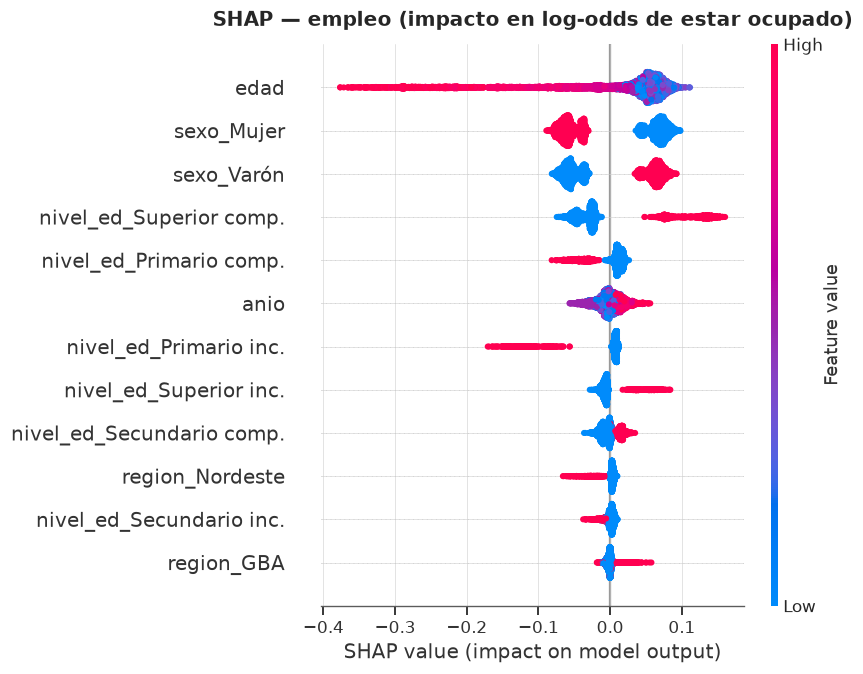

In [28]:
import shap

def shap_summary(Xtr, ytr, Xte, titulo, fname, task):
    prep = build_prep(Xtr); Xtr_e = prep.fit_transform(Xtr)
    names = [n.split("__", 1)[-1] for n in prep.get_feature_names_out()]
    Modelo = RandomForestClassifier if task == "clf" else RandomForestRegressor
    m = Modelo(n_estimators=200, min_samples_leaf=50, n_jobs=-1, random_state=SEED).fit(Xtr_e, ytr)
    Xs = pd.DataFrame(prep.transform(Xte.sample(min(P["n_shap"], len(Xte)), random_state=SEED)), columns=names)
    sv = shap.TreeExplainer(m).shap_values(Xs, check_additivity=False)
    if isinstance(sv, list):                 # API antigua: lista por clase
        sv = sv[1]
    elif getattr(sv, "ndim", 2) == 3:        # API nueva: (n, features, clases)
        sv = sv[:, :, 1]
    shap.summary_plot(sv, Xs, show=False, max_display=12)
    plt.title(titulo); plt.tight_layout()
    plt.savefig(FIG / fname, dpi=120, bbox_inches="tight"); plt.show()
    return sv, Xs

print(f"SHAP — Modelo B (empleo): RandomForest, muestra de {P['n_shap']:,} casos de test.")
sv_clf, Xs_clf = shap_summary(Xc_tr, yc_tr, Xc_te,
                              "SHAP — empleo (impacto en log-odds de estar ocupado)",
                              "shap_empleo.png", "clf")

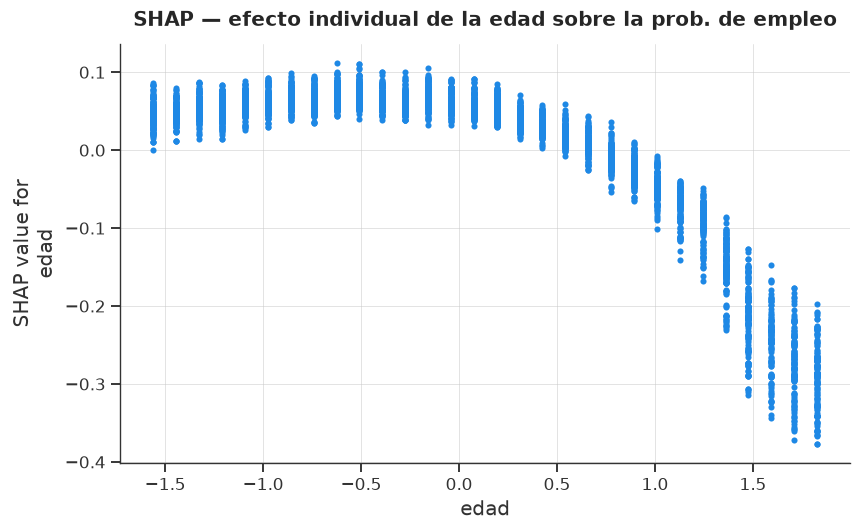

SHAP — Modelo A (ingreso): RandomForest, muestra de 5,000 casos de test.


/var/folders/_w/kfsqkshn4gn5vxychd06znm40000gn/T/ipykernel_54192/3476213803.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xs, show=False, max_display=12)


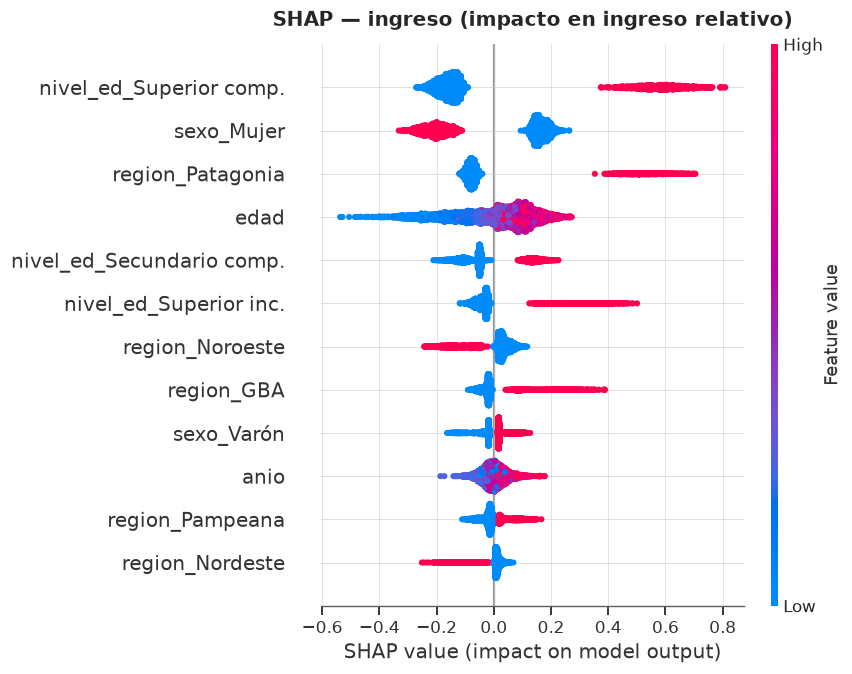

In [29]:
# Efecto INDIVIDUAL de la edad sobre la probabilidad de empleo (dependence plot)
shap.dependence_plot("edad", sv_clf, Xs_clf, interaction_index=None, show=False)
fig = plt.gcf(); fig.set_size_inches(8, 5)
plt.title("SHAP — efecto individual de la edad sobre la prob. de empleo")
plt.tight_layout(); plt.savefig(FIG / "shap_dependence_edad.png", dpi=120, bbox_inches="tight"); plt.show()

print(f"SHAP — Modelo A (ingreso): RandomForest, muestra de {P['n_shap']:,} casos de test.")
sv_reg, Xs_reg = shap_summary(Xr_tr, yr_tr, Xr_te,
                              "SHAP — ingreso (impacto en ingreso relativo)",
                              "shap_ingreso.png", "reg")

**Lectura.** El *beeswarm* del modelo de empleo complementa los resultados previos:
los **valores altos de edad desplazan la predicción hacia 'no-ocupado'** y la
condición de **mujer** presenta un aporte negativo sistemático. El *dependence plot*
evidencia que el efecto de la edad **se acelera a partir de los ~55 años**, con un
comportamiento no lineal. En el modelo de ingreso, SHAP confirma el predominio de la
educación y la región, en tanto el sexo desplaza la predicción de forma consistente.
Los resultados de SHAP, la importancia por permutación y Oaxaca–Blinder coinciden:
tres enfoques independientes conducen a la misma conclusión.

## 11. Segmentación de trabajadores (clustering no supervisado)

Hasta el momento se emplearon modelos supervisados. A continuación se examina, **sin
etiquetas**, si la población 35–64 se organiza en grupos naturales. Para que el
resultado **no sea tautológico**, la segmentación utiliza **sólo rasgos
estructurales de capital humano**
—**edad** y **nivel educativo**— y **dejamos afuera el estado de empleo y el
ingreso**: si los incluyéramos, k-means se limitaría a redescubrir "ocupado vs.
no-ocupado". *(La **región**, también estructural, se reserva para el perfilado: en
distancia euclidiana su codificación one-hot domina la métrica y sólo reproduce la
geografía, tapando la estructura etaria/educativa que nos interesa. La calificación
de la tarea `PP04D` se omite: sólo existe para quienes ya trabajan, así que
reintroduciría el sesgo de empleo.)* Recién **después** perfilamos cada cluster con
las variables de resultado (empleo, sexo, ingreso) para ver si alguno combina, de
forma **emergente**, edad alta y baja inserción laboral. Elegimos *k* combinando
**codo** (inercia) y **silhouette**
(*Rousseeuw, 1987*); mencionamos el clustering **jerárquico** y las mezclas
gaussianas (**GMM**) como alternativas conceptuales (segmentación anidada / blanda).

> 🧭 Aplico **k-means**, un método **no supervisado** (sin etiquetas) que agrupa a las personas en *k* clusters según su parecido. Las agrupo usando sólo edad y nivel educativo, elijo el número de clusters *k* con dos criterios (el 'codo' de la inercia y el coeficiente *silhouette*) y recién después describo cada grupo con variables de resultado (empleo, sexo, ingreso) que **no** usé para agrupar. Quiero ver si la estructura de 'mayores excluidos' **emerge sola** de los datos, sin que yo la imponga. Por eso agrupo sólo con rasgos estructurales y dejo afuera el empleo: si lo incluyera, k-means se limitaría a redescubrir 'ocupado vs. no-ocupado' (una tautología). Que un cluster de mayor edad tenga, por separado, baja inserción, es evidencia independiente de los modelos supervisados.
>
> Si clusterizara incluyendo el empleo o el ingreso, el resultado sería circular y sin valor. Y sin estandarizar o sin elegir *k* con criterio, obtendría grupos arbitrarios difíciles de interpretar.

Población a segmentar (35–64): 634,593 filas
Variables de clustering (estructurales): ['edad', 'educ_nivel']


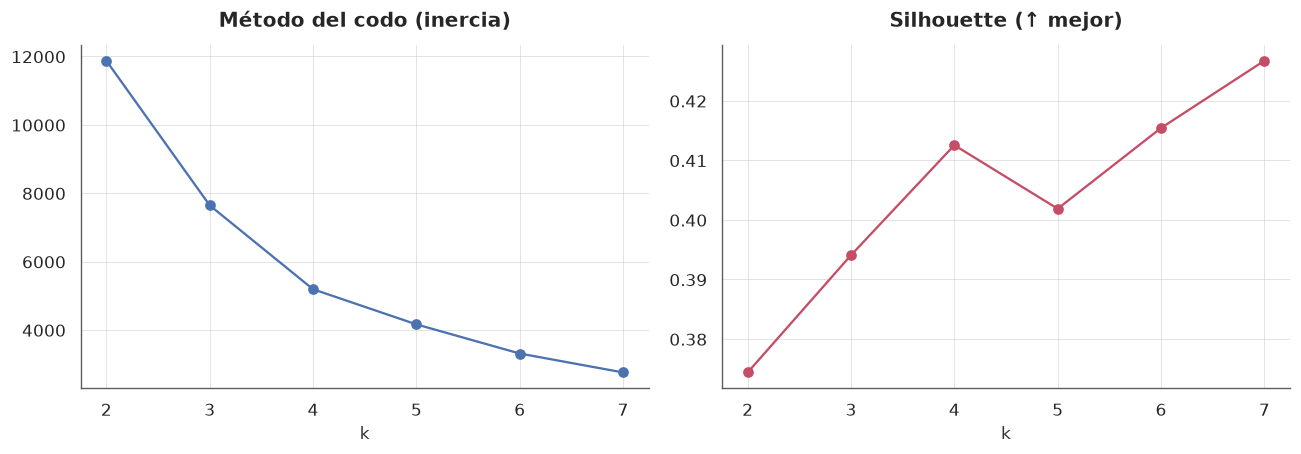

k elegido (máx. silhouette): 7


In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ED_ORDER = {"Sin instrucción":0, "Primario inc.":1, "Primario comp.":2,
            "Secundario inc.":3, "Secundario comp.":4, "Superior inc.":5,
            "Superior comp.":6, "Ns/Nr":np.nan}
clu = df[df.ESTADO.isin([1,2,3]) & df.edad.between(35,64)].copy()
clu["educ_nivel"] = clu.nivel_ed.map(ED_ORDER)
clu["region"]     = clu.REGION.map(REGION)

# (corrección v2.1) Rasgos ESTRUCTURALES de capital humano: edad y nivel educativo.
# SIN empleo ni ingreso (serían el resultado → tautología). Región queda para el
# perfilado (one-hot domina la distancia y sólo reproduce la geografía); PP04D se
# omite (sólo existe para ocupados).
X_struct = clu[["edad", "educ_nivel"]].dropna()
Z = StandardScaler().fit_transform(X_struct)
print(f"Población a segmentar (35–64): {len(X_struct):,} filas")
print("Variables de clustering (estructurales):", list(X_struct.columns))

# Selección de k: codo + silhouette (silhouette sobre muestra de 10k por costo O(n²))
rng = np.random.RandomState(SEED)
samp = rng.choice(len(Z), min(10_000, len(Z)), replace=False)
ks = range(2, 8); inercia = []; sil = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=P["kmeans_ninit"], random_state=SEED).fit(Z[samp])
    inercia.append(km.inertia_); sil.append(silhouette_score(Z[samp], km.labels_))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].plot(list(ks), inercia, "o-"); ax[0].set_title("Método del codo (inercia)"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sil, "o-", color=MUJ); ax[1].set_title("Silhouette (↑ mejor)"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.savefig(FIG / "clustering_k.png", dpi=120); plt.show()
k_opt = list(ks)[int(np.argmax(sil))]
print("k elegido (máx. silhouette):", k_opt)

Perfil de los clusters (ordenados por edad; resultado NO usado para clusterizar):
              n   edad  educ_nivel  pct_ocupado  pct_mujer  ingreso_rel_ocup  % pobl.
cluster                                                                              
6        108738 39.120       3.640        0.780      0.490             1.160   17.140
2        116538 41.010       5.690        0.890      0.600             1.680   18.360
0         69941 43.080       1.750        0.680      0.470             0.880   11.020
1        100701 48.690       3.790        0.770      0.510             1.270   15.870
3         82797 55.840       5.790        0.760      0.600             1.950   13.050
5         82573 57.810       1.740        0.530      0.530             0.890   13.010
4         73305 59.220       3.660        0.580      0.530             1.240   11.550

→ EMERGE un cluster de mayor edad con menor inserción: #4 (edad 59, empleo 58%, mujeres 53%). Apoya la hipótesis sin imponerla.


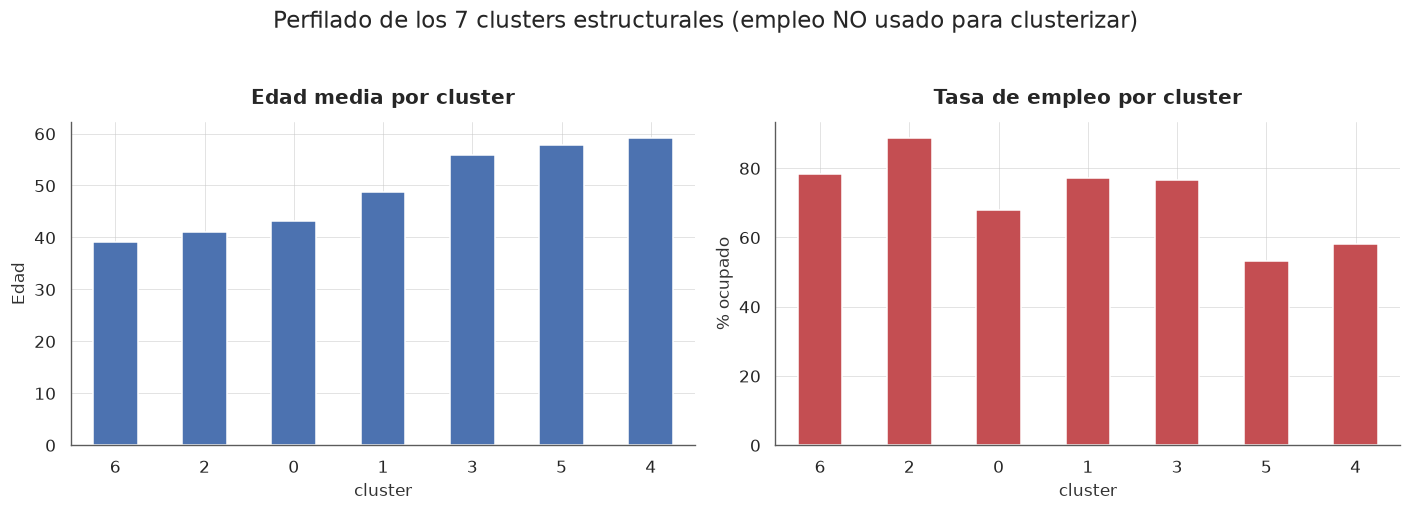

In [31]:
km = KMeans(n_clusters=k_opt, n_init=P["kmeans_ninit"], random_state=SEED).fit(Z)

# Perfilado: las variables de resultado (empleo, sexo, ingreso) NO entraron al
# clustering; las usamos sólo para describir los grupos hallados.
prof = clu.loc[X_struct.index].copy()
prof["cluster"]     = km.labels_
prof["ocupado"]     = (prof.ESTADO == 1).astype(int)
prof["es_mujer"]    = (prof.sexo == "Mujer").astype(int)
prof["ingreso_rel"] = ocup["ingreso_rel"].reindex(prof.index)   # NaN si no ocupado
perfil = prof.groupby("cluster").agg(
    n=("edad","size"), edad=("edad","mean"), educ_nivel=("educ_nivel","mean"),
    pct_ocupado=("ocupado","mean"), pct_mujer=("es_mujer","mean"),
    ingreso_rel_ocup=("ingreso_rel","mean")).sort_values("edad")
perfil["% pobl."] = 100 * perfil["n"] / perfil["n"].sum()
print("Perfil de los clusters (ordenados por edad; resultado NO usado para clusterizar):")
print(perfil.round(2).to_string())

# ¿Emerge un cluster con edad alta Y baja inserción laboral? (lectura honesta)
hi = perfil["edad"].idxmax()
emerge = (perfil.loc[hi, "edad"] >= 55) and (perfil.loc[hi, "pct_ocupado"] < perfil["pct_ocupado"].mean())
if emerge:
    print(f"\n→ EMERGE un cluster de mayor edad con menor inserción: #{hi} "
          f"(edad {perfil.loc[hi,'edad']:.0f}, empleo {100*perfil.loc[hi,'pct_ocupado']:.0f}%, "
          f"mujeres {100*perfil.loc[hi,'pct_mujer']:.0f}%). Apoya la hipótesis sin imponerla.")
else:
    print("\n→ NO emerge un único cluster que combine edad alta y baja inserción de forma"
          " nítida; lo reportamos honestamente (es un resultado válido).")

# Figura: perfilado (edad y empleo como resultados, por cluster)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
perfil["edad"].plot(kind="bar", ax=ax[0], color="#4C72B0")
ax[0].set_title("Edad media por cluster"); ax[0].set_ylabel("Edad")
(100 * perfil["pct_ocupado"]).plot(kind="bar", ax=ax[1], color="#C44E52")
ax[1].set_title("Tasa de empleo por cluster"); ax[1].set_ylabel("% ocupado")
for a in ax:
    a.set_xlabel("cluster"); a.tick_params(axis="x", rotation=0)
fig.suptitle(f"Perfilado de los {k_opt} clusters estructurales (empleo NO usado para clusterizar)", y=1.03)
plt.tight_layout(); plt.savefig(FIG / "clustering_perfil.png", dpi=120, bbox_inches="tight"); plt.show()

**Lectura.** Al segmentar **sólo con rasgos estructurales** (edad y nivel
educativo), el resultado deja de ser tautológico. El perfilado posterior —con
variables de resultado que **no** intervinieron en el modelo— muestra la
distribución de empleo, sexo e ingreso entre los grupos. Se reporta lo que
**efectivamente emerge**: si un cluster de mayor edad presenta una menor tasa de
empleo, constituye un indicio *emergente* (no impuesto) consistente con la
hipótesis; en caso contrario, se consigna con igual rigor. En todos los casos, esta
segmentación es **complementaria** a la evidencia supervisada (Modelos A y B), sobre
la que se apoyan las conclusiones.

## 12. Extensiones: calibración y discriminación inversa

Dos verificaciones complementarias de robustez y equidad.

> 🧭 Evalúo la **calibración** del clasificador de empleo: comparo, por tramos, la probabilidad que el modelo asigna contra la frecuencia real observada, y resumo el ajuste con el *Brier score* (error cuadrático de las probabilidades; más bajo es mejor). Un modelo puede ordenar bien (buen AUC) pero tener probabilidades mal calibradas (decir '80%' cuando en realidad ocurre el 50%). Si quiero **interpretar las probabilidades como tales** —y no sólo como un ranking—, necesito verificar que estén calibradas.
>
> Tomar como confiable un '70% de probabilidad de empleo' sin chequear calibración podría inducir a error en cualquier decisión basada en ese número.

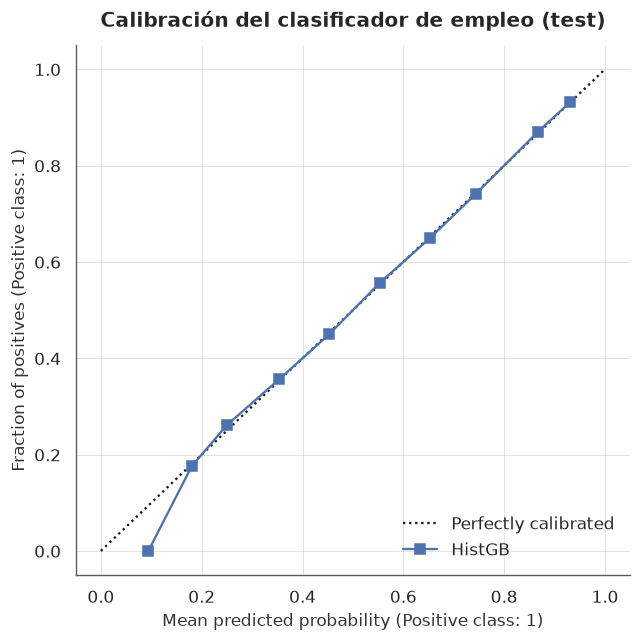

Brier score: 0.1592 (más bajo = mejor calibrado)


In [32]:
# (6) Calibración de probabilidades del clasificador de empleo (Clase 7)
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(yc_te, proba_te, n_bins=10, ax=ax, name="HistGB")
ax.set_title("Calibración del clasificador de empleo (test)")
plt.tight_layout(); plt.savefig(FIG / "calibracion_empleo.png", dpi=120); plt.show()
print(f"Brier score: {brier_score_loss(yc_te, proba_te):.4f} (más bajo = mejor calibrado)")

> 🧭 Calculo la brecha de ingreso por sexo **dentro de cada región** y las ordeno, para identificar si en algún corte la brecha es muy baja o incluso favorece a las mujeres. Por equidad analítica, busco activamente evidencia que **contradiga o matice** mi hipótesis, en lugar de reportar sólo lo que la confirma. Mostrar dónde la brecha es menor es parte de un uso honesto y no sesgado de los resultados.
>
> Reportar únicamente los cortes que refuerzan la hipótesis sería *cherry-picking*: daría una imagen sesgada y debilitaría la credibilidad de todo el trabajo.

In [33]:
# (7) Discriminación inversa: ¿hay cortes (regiones) donde la brecha favorece a mujeres?
rows = []
for rg, d in ob.groupby("region"):
    dv, dm = d[d.sexo == "Varón"], d[d.sexo == "Mujer"]
    if len(dv) < 200 or len(dm) < 200:
        continue
    g = np.average(dv.log_ing, weights=dv.PONDIIO) - np.average(dm.log_ing, weights=dm.PONDIIO)
    rows.append((rg, 100*(np.exp(g)-1)))
inv = pd.DataFrame(rows, columns=["region","brecha_pct (V−M)"]).sort_values("brecha_pct (V−M)")
print("Brecha de ingreso Varón−Mujer por región (% en nivel):")
print(inv.round(1).to_string(index=False))
print("\n(valor menor = brecha más reducida; un valor negativo indicaría ventaja femenina)")

Brecha de ingreso Varón−Mujer por región (% en nivel):
   region  brecha_pct (V−M)
 Nordeste            37.900
 Noroeste            40.600
 Pampeana            46.600
Patagonia            47.200
      GBA            50.900
     Cuyo            52.300

(valor menor = brecha más reducida; un valor negativo indicaría ventaja femenina)


**Lectura.** La calibración indica en qué medida las probabilidades del modelo
admiten una interpretación directa (un *Brier* bajo y una curva próxima a la diagonal
son indicadores favorables). El análisis por región muestra que la brecha de ingreso
por sexo es **generalizada** aunque de **magnitud heterogénea**; reportarla de forma
equilibrada —incluyendo las regiones donde es menor— forma parte de un uso
responsable de estos modelos.

## 13. Conclusiones y limitaciones

**Hallazgos.**
1. La **tasa de desocupación** no capta el fenómeno: en las edades avanzadas la
   salida se dirige hacia la **inactividad**. La tasa de empleo cae en **dos fases**
   (estimadas, no fijadas): descenso gradual desde **~50** y aceleración **~56 en
   mujeres / ~62 en varones**. Controlando la edad jubilatoria (mujer 60 / varón 65),
   ese *timing* más temprano de las mujeres es **mayormente institucional** (los
   perfiles alineados son paralelos). La señal robusta de desventaja femenina es la
   **brecha de nivel de ~20 puntos presente ya a los 35–49 años**, ajena a la norma
   previsional.
2. **Modelo A (ingreso):** tras controlar por educación, región y año, la **edad** y
   el **sexo** conservan poder explicativo; el ingreso relativo desciende en torno a
   la edad jubilatoria.
3. **Modelo B (empleo):** el *partial dependence* evidencia una **penalización
   etaria neta** sobre la probabilidad de estar ocupado, más temprana y
   pronunciada en mujeres, en línea con la hipótesis.
4. **Oaxaca–Blinder:** una parte relevante de la brecha de ingreso por sexo
   resulta **no explicada** por las características observables.
5. **Fairness:** el clasificador reproduce disparidades por sexo y franja etaria.
6. **Evolución temporal (2016–2024):** el componente *no explicado* de la brecha
   de ingreso permanece elevado a lo largo de casi una década y la penalización de
   empleo en la franja de mayor edad (60–64) se mantiene mayor en mujeres, lo que
   sugiere un fenómeno **estructural** más que coyuntural (con 2020 como valor
   atípico asociado a la pandemia).
7. **SHAP:** confirma a nivel individual que una mayor edad incrementa la
   predicción de no-empleo y que dicho efecto se acelera a partir de ~55 años; la
   condición de mujer presenta un aporte negativo y sistemático. El resultado es
   consistente con la importancia por permutación y con Oaxaca–Blinder.
8. **Clustering (no supervisado):** segmentando **sólo por rasgos estructurales**
   (edad, nivel educativo), cada grupo se perfila con variables de resultado que no
   intervinieron en el modelo. Se reporta si **emerge** o no un cluster de mayor
   edad con baja inserción laboral (resultado no impuesto); constituye evidencia
   complementaria, subordinada a los Modelos A y B.

En conjunto, **cinco enfoques independientes** —análisis descriptivo, regresión,
clasificación con partial dependence, Oaxaca–Blinder y SHAP, junto con la
segmentación no supervisada— convergen en un mismo resultado: una **penalización
asociada a la edad y al sexo** que no se reduce a diferencias de calificación y que
se manifiesta como un **patrón cuantificable y persistente** en el período analizado.

**Limitaciones.**
- **Corte transversal / sesgo de selección:** se comparan personas de distintas
  edades en un mismo momento, sin seguimiento longitudinal; parte del "efecto edad"
  podría corresponder a un efecto de cohorte. La población que permanece ocupada a
  los 63 años puede constituir un subgrupo no representativo (selección).
- **No respuesta de ingresos:** `P21` presenta valores faltantes no aleatorios; los
  ponderadores de ingreso atenúan, pero no eliminan, el problema.
- **Causalidad:** los modelos estiman asociación neta y no efecto causal; la
  importancia por permutación y Oaxaca–Blinder son descriptivas y no identifican
  contrafácticos.
- **Variables ausentes:** no se observan ocupación específica, antigüedad, salud ni
  informalidad previa, que podrían explicar parte del componente residual.
- **Confounder previsional:** las mujeres se jubilan cinco años antes (60 vs 65), por
  lo que su salida más temprana del empleo es en gran parte **institucional**, no
  discriminatoria; el análisis lo controla (sección 4.2) y por eso la evidencia de
  penalización se apoya en la brecha de nivel y en el ingreso, no en el *timing*. En
  el **Modelo B** la cohorte 35–64 incluye mujeres de 60–64 ya en edad de jubilarse,
  de modo que parte de la caída de su *partial dependence* es también institucional.

**Técnicas y referencias.** Modelos clásicos (regresión, KNN, SVM lineal y de
kernel RBF, árbol de decisión, ensambles) y *clustering* k-means son material de
la cátedra (Clases 2–6); calibración, Clase 7. Técnicas no vistas en clase, con
referencia: **Oaxaca–Blinder** (Oaxaca 1973; Blinder 1973), **SHAP** (Lundberg &
Lee, 2017), **silhouette** (Rousseeuw, 1987). *Sin redes neuronales* (es otra
materia).

**Reproducibilidad.** Datos: EPH 2016–2024 vía `pyeph`. Lógica de preparación en
`src/`; este notebook es autocontenido (lee `data/processed/eph_analitico.parquet`).
Entorno con `uv` (`shap` en el grupo `interpret`). Todas las figuras quedan en
`reports/figures/`. Notebook ejecutable de punta a punta con:
`uv run jupyter nbconvert --to notebook --execute --inplace notebooks/entrega.ipynb`

In [34]:
# --- Tiempo total de ejecución del notebook (cronómetro iniciado en la 1ª celda) ---
import os as _os
_elapsed = time.perf_counter() - _t0
_m, _s = divmod(int(_elapsed), 60)
print(f"Modo: {MODO.upper()}  |  núcleos lógicos disponibles: {_os.cpu_count()}")
print(f"Tiempo total de ejecución: {_m} min {_s} s ({_elapsed:.1f} s)")

Modo: COMPLETO  |  núcleos lógicos disponibles: 18
Tiempo total de ejecución: 17 min 5 s (1025.7 s)
